## 1. 目的と評価指標の整理
* 目的：testデータの各idについて、次ラップでピットインするか（PitNextLap）を予測する
* タスク：二値分類
  * 「次ラップでピットインする（1）確率」を予測する

* 評価指標：ROC AUC
  * 実際にピットインするデータを、ピットインしないデータより高い確率で予測できているかを評価する指標
  * ピットインする可能性が高い順に正しく並べられているか

* 提出形式：id, PitNextLap
  * testデータのIDごとに、次ラップでピットインする確率を提出する

* 注意：データは実データではなく、合成データ（synthetic data）
---
F1戦略データをもとに作成された synthetic data のため、
* 実際のF1戦略として自然か
* synthetic特有の規則性がないか
* train/test分布差がないか

を確認しながら分析を進める必要がある

## 0-1. 共通準備（毎回実行）

In [ ]:
# Google Drive をマウント
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 参照フォルダ
base_path = "/content/drive/MyDrive/Kaggle研究会/playground-series-s6e5"

train = pd.read_csv(f"{base_path}/train.csv")
test = pd.read_csv(f"{base_path}/test.csv")
sample_sub = pd.read_csv(f"{base_path}/sample_submission.csv")

target = "PitNextLap"
id_col = "id"

features = [c for c in train.columns if c not in [id_col, target]]

cat_cols = train[features].select_dtypes(include="object").columns.tolist()
num_cols = train[features].select_dtypes(exclude="object").columns.tolist()

print("目的変数:", target)
print("特徴量数:", len(features))
print("カテゴリ型特徴量:", cat_cols)
print("数値特徴量数:", len(num_cols))

Mounted at /content/drive
目的変数: PitNextLap
特徴量数: 14
カテゴリ型特徴量: ['Driver', 'Compound', 'Race']
数値特徴量数: 11


In [ ]:
feature_summary = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str).values,
    "missing": train.isna().sum().values,
    "nunique": train.nunique().values
})

feature_summary

,column,dtype,missing,nunique
0,id,int64,0,439140
1,Driver,object,0,887
2,Compound,object,0,5
3,Race,object,0,26
4,Year,int64,0,4
5,PitStop,int64,0,2
6,LapNumber,int64,0,78
7,Stint,int64,0,8
8,TyreLife,float64,0,78
9,Position,int64,0,20


## 0-2. ドメイン知識

#### **F1の基礎知識**
* F1は世界最高峰のモータースポーツカテゴリー
* 1チーム2名のドライバーが出場する
* 2025年までは10チーム20台、2026年から11チーム22台
* 1シーズンは複数のGPで構成され、各レース順位に応じてポイントが付与される
* シーズン終了時に最もポイントを獲得したドライバー・チームが年間王者となる
* 決勝レースは原則約305km、多くは50〜70周前後
* 各GPは金曜日にフリー走行（FP1、FP2）、土曜日にフリー走行（FP3）と予選（Q1、Q2、Q3）、日曜日に決勝レースがある
* 予選では、全ドライバーがQ1に参加し、最速15人（※1）がQ2に進出する。 Q2最速の10人がQ3に進出。 Q3の結果で決勝のスターティンググリッドが決まり、トップタイムが1番手となる。　※1：2026年は16人

#### **ピットストップとは**
* PitStop（ピットストップ）
    * レース中にピットインし（ピットレーンに入り）、自身のピット前の作業エリアで**主にタイヤ交換**を行うこと
    * 2010年以降、決勝中の給油は禁止されている

#### **タイヤの種類**
* 2022年からはイタリアの『ピレリ』が供給するタイヤを全チーム使用（2027年まで予定）
* タイヤのコンパウンド（種類）は**ドライタイヤ**と**レインタイヤ**がある
    * **ドライタイヤ**：各レース事前に5種類（2023年、2025年は6種類）から**ハード**（白）、**ミディアム**（黄）、**ソフト**（赤）の3種類を選択される
        * FIAとピレリによってF1が開催されるサーキットの路面や気温などの特性を考する
        * 柔らかいコンパウンド：グリップ力が高く、耐久性が低い特性を持っている ⇒ 速いがタイヤ劣化しやすい
        * 硬いコンパウンド：グリップ力が低く、耐久性が高い特性を持っている タイヤの持ちはいいが遅い
    * **レインタイヤ**：**インターミディエイト**（緑）と**ウェット**（青）の2種類が設定されている
        * インターミディエイト タイヤ：浅溝で小雨のように雨量が少ない場合や雨があがりのように路面が乾いてきたような場合に使用される
        * ウェットタイヤ：深溝で水はけ性能が高く、雨天時のタイヤとして使用
    * 各グランプリにおいてドライバーごとに供給されるタイヤのセット数がレギュレーション（F1で定められているルール・技術規則）で定められてる

#### **タイヤ交換のルール（ピットインに関係がある）**
* F1ではレース中に**1回以上のタイヤ交換**を行うことが義務付けられている
* レース中に**2種類以上のコンパウンドのタイヤを使用**しないといけない
* 決勝用として供給された**ハードタイヤもしくはミディアムタイヤのうち、どちらかのタイヤを使用する必要がある**


#### 特徴量に関する補足情報

**3.   Race（レース名）**：
*   Race は単なるレース名ではなく、サーキット特性差を含む可能性がある
*   実際のF1では、レースごとにコース幅、オーバーテイク難易度、タイヤ負荷、セーフティカー（SC）発生率、ピットロス時間などが異なる
    *   モナコGPは、コース幅が非常に狭い、追い越しが極めて難しい、市街地コース、クラッシュ・SCが発生しやすいなどの特徴があり、コース上で抜きにくいためピット戦略が重要とされている
    *   一方、バーレーンGPやオーストリアGPは、比較的オーバーテイク（前を走っている車を追い抜いて順位を上げること）しやすい、タイヤ差を活かしやすい、2ストップなどの攻めた戦略を取りやすいなどの特徴がある
    *   レースごとに、主な戦略、ピット回数、タイヤ寿命、使用するタイヤの種類、などが異なる可能性がある
*   今回のデータは synthetic data（合成データ） のため、現実のF1特性が完全再現されているとは限らない
*   そのためEDA（探索的データ分析）で、RaceごとのPit率、RaceごとのCompound傾向、RaceごとのTyreLifeなどを確認し、実際にデータ上でも傾向差があるか確認したほうが良いと考える

**4.   Year（開催年）**：
*   2022～2025年は細かい変更はあるものの、予測に関係する主要ルールは大きく変わっていない
    *   レース中給油禁止（2010年以降継続）⇒ピット = 主に**タイヤ交換**
    *   最低2種類のドライタイヤ使用義務→通常は**最低1回ピット**
    *   2022年に13インチタイヤから18インチタイヤへ変更
    *   基本コンパウンド（**SOFT、MEDIUM、HARD、INTERMEDIATE、WET**の基本構造も継続）
    *   戦略構造も大きくは変わっていない（**1ストップ・2ストップ**中心）

### **レース戦略と分析方針**

#### **レース戦略**
F1では、次ラップでピットインするかどうかは、単純なタイヤ寿命だけではなく、複数のレース戦略によって決まる。

主な戦略として、以下が考えられる。

* 1ストップ / 2ストップ戦略：タイヤ劣化への対応
* セーフティカー（SC）戦略
    * セーフティーカー：事故などで出動し全車が減速し、追い越し禁止になる状態
    * 通常より少ないロスでピットできるため、ピットが増えやすい
    * バーチャルセーフティーカー：事故やコース上の危険時に導入され、実際のセーフティカーを出さずに全車に一定の減速・速度制限を課して安全を確保するための運用方式
* アンダーカット：ライバルより先にピットし、新しいタイヤで速く走って順位逆転を狙う戦略 ⇒ タイヤ温存
* オーバーカット：ライバルより長く走り、ピット前にタイムを稼いで順位逆転を狙う戦略 ⇒ トラックポジション重視

* Track Position：
    * コース上の位置・順位
    * 抜きにくいサーキットでは特に重要

#### **分析方針**
* 今回の特徴量には、セーフティカーやアンダーカットなどの戦略を直接表す列は存在しない。
1. そのため、まずはベースラインモデルを構築し、モデルがどの特徴量を重視しているかを確認する。
2. また、特徴量重要度やSHAPを用いて、モデルがピット判断に利用している要因を分析する。
3. その結果を踏まえ、タイヤ劣化・レース進行状況・順位変動などの情報を組み合わせた特徴量を追加し、予測精度の改善を図る。
4. そのあとに、誤分類分析を実施し、以下のケースを確認することで、モデルが捉えられていないレース戦略の存在を検討する。
    * 実際はピットするのに低く予測したケース
    * 実際はピットしないのに高く予測したケース

例えば、
* TyreLife が高いのにピットしない → タイヤ温存・1ストップ戦略の可能性
* TyreLife が低いのにピットする → SC戦略・アンダーカットの可能性
* RaceProgress 中盤で予測を外す → 1ストップ / 2ストップ判断の違い
* Position_Change が大きいケースで外す → 戦略変更やTrack Positionの影響
* などの仮説を立て、特徴量エンジニアリングにつなげる。

## 0-3. 特徴量の整理（毎回実行）

In [ ]:
jp_labels = {
    "id": "ID",
    "Driver": "ドライバー名",
    "Compound": "タイヤの種類",
    "Race": "レース名",
    "Year": "開催年",
    "PitStop": "現在ラップでピットインしたか",
    "LapNumber": "現在のラップ数",
    "Stint": "スティント（タイヤ使用数）",
    "TyreLife": "タイヤ使用周回数",
    "Position": "現在順位",
    "LapTime (s)": "ラップタイム（秒）",
    "LapTime_Delta": "前ラップ比ラップタイム差",
    "Cumulative_Degradation": "累積タイヤ劣化",
    "RaceProgress": "レース進行率",
    "Position_Change": "順位変動",
    "PitNextLap": "次ラップでピットインするか"
}

feature_reason = {
    "id": "識別用ID",
    "Driver": "走行スタイル差",
    "Compound": "タイヤ劣化特性差",
    "Race": "サーキット特性差",
    "Year": "レギュレーション差",
    "PitStop": "直後は再ピットしにくい",
    "LapNumber": "ピットしやすい周回帯がある",
    "Stint": "戦略段階を示す",
    "TyreLife": "タイヤ劣化の直接指標",
    "Position": "順位により戦略が変わる",
    "LapTime (s)": "現在のペース状態を示す",
    "LapTime_Delta": "劣化やペース低下の兆候",
    "Cumulative_Degradation": "累積劣化がピット判断に影響",
    "RaceProgress": "レース終盤ほど戦略判断が変わる",
    "Position_Change": "順位変動で戦略変更が起きる",
    "PitNextLap": "目的変数"
}

feature_summary["日本語名"] = (
    feature_summary["column"]
    .map(jp_labels)
    .fillna("")
)

feature_summary["目的変数との関係性"] = (
    feature_summary["column"]
    .map(feature_reason)
    .fillna("")
)

feature_summary

,column,dtype,missing,nunique,日本語名,目的変数との関係性
0,id,int64,0,439140,ID,識別用ID
1,Driver,object,0,887,ドライバー名,走行スタイル差
2,Compound,object,0,5,タイヤの種類,タイヤ劣化特性差
3,Race,object,0,26,レース名,サーキット特性差
4,Year,int64,0,4,開催年,レギュレーション差
5,PitStop,int64,0,2,現在ラップでピットインしたか,直後は再ピットしにくい
6,LapNumber,int64,0,78,現在のラップ数,ピットしやすい周回帯がある
7,Stint,int64,0,8,スティント（タイヤ使用数）,戦略段階を示す
8,TyreLife,float64,0,78,タイヤ使用周回数,タイヤ劣化の直接指標
9,Position,int64,0,20,現在順位,順位により戦略が変わる


## 2. データ定義

In [ ]:
# 英語列名 → 日本語名 変換関数
def jp(col):
    return jp_labels.get(col, col)

# 基本情報
print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_sub.shape)

# 目的変数・特徴量
print("目的変数:", target, "→", jp(target))
print("特徴量数:", len(features))
print("数値特徴量:", len(num_cols), num_cols)
print("カテゴリ特徴量:", len(cat_cols), cat_cols)

# 中身確認
display(train.head())
display(test.head())
display(sample_sub.head())

train: (439140, 16)
test: (188165, 15)
sample_submission: (188165, 2)
目的変数: PitNextLap → 次ラップでピットインするか
特徴量数: 14
数値特徴量: 11 ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
カテゴリ特徴量: 3 ['Driver', 'Compound', 'Race']


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,0


確認結果
*   train は439,140行、test は188,165行
*   1行は「あるドライバーのある周回時点」のレース状況を表す
*   特徴量は14列で、数値11列・カテゴリ3列で構成
*   id は識別子のため、モデル学習には使用しない

## 3. データ粒度確認

In [ ]:
# ■ 3-1) id の一意性確認
print("■ idの一意性")

if "id" in train.columns and "id" in test.columns:
    print("train id unique:", train["id"].is_unique)
    print("test  id unique:", test["id"].is_unique)

# ■ 3-2) 重複行確認
print("\n■ 重複行確認")

print("train duplicated rows:", train.duplicated().sum())
print("test  duplicated rows:", test.duplicated().sum())

# ■ 3-3) id重複確認
print("\n■ id重複確認")

dup_id = train["id"].duplicated().sum()
print("train duplicated id:", dup_id)

if dup_id > 0:
    display(
        train[
            train["id"].duplicated(keep=False)
        ].sort_values("id").head(10)
    )

# ■ 3-4) 目的変数確認
print("\n■ 目的変数確認")

print("target:", target)
print("dtype :", train[target].dtype)

print("\nクラス数:", train[target].nunique())

print("\nクラス分布")
display(
    train[target]
    .value_counts(dropna=False)
    .to_frame("count")
)

■ idの一意性
train id unique: True
test  id unique: True

■ 重複行確認
train duplicated rows: 0
test  duplicated rows: 0

■ id重複確認
train duplicated id: 0

■ 目的変数確認
target: PitNextLap
dtype : float64

クラス数: 2

クラス分布


,count
PitNextLap,
0.0,351759
1.0,87381


確認結果

*   id は一意で、重複行・id重複はない
*   目的変数は PitNextLap（次ラップでピットするか）
*   0 / 1 の二値分類問題である
*   目的変数の欠損はない
*   Pitなしが約80%、Pitありが約20%で、クラス不均衡がある

## 4. 欠損・型確認

In [ ]:
all_cols = features + [target]

# 4-1) 欠損率・型・ユニーク数を一覧化
summary = pd.DataFrame({
    "列名": all_cols,
    "日本語訳": [jp(c) for c in all_cols],
    "役割": ["説明変数"] * len(features) + ["目的変数"],
    "dtype": [train[c].dtype for c in all_cols],
    "欠損数_train": [train[c].isna().sum() for c in all_cols],
    "欠損率_train_%": [(train[c].isna().mean() * 100).round(2) for c in all_cols],
    "欠損数_test": [test[c].isna().sum() if c in test.columns else None for c in all_cols],
    "欠損率_test_%": [(test[c].isna().mean() * 100).round(2) if c in test.columns else None for c in all_cols],
    "ユニーク数_train": [train[c].nunique(dropna=True) for c in all_cols],
})

display(summary.sort_values(["役割", "列名"]))

# 4-2) 数値列・カテゴリ列の確認
print("数値列:", len(num_cols), num_cols)
print("カテゴリ列:", len(cat_cols), cat_cols)

# 4-3) train/testでカテゴリの種類がズレていないか確認
for c in cat_cols:
    train_set = set(train[c].dropna().unique())
    test_set = set(test[c].dropna().unique())

    only_train = train_set - test_set
    only_test = test_set - train_set

    print(f"\n[カテゴリ差分確認] {c}: {jp(c)}")
    print("trainにだけある値:", only_train if len(only_train) > 0 else "なし")
    print("testにだけある値:", only_test if len(only_test) > 0 else "なし")

,列名,日本語訳,役割,dtype,欠損数_train,欠損率_train_%,欠損数_test,欠損率_test_%,ユニーク数_train
14,PitNextLap,次ラップでピットインするか,目的変数,float64,0,0.0,NaN,NaN,2
1,Compound,タイヤの種類,説明変数,object,0,0.0,0.0,0.0,5
11,Cumulative_Degradation,累積タイヤ劣化,説明変数,float64,0,0.0,0.0,0.0,142701
0,Driver,ドライバー名,説明変数,object,0,0.0,0.0,0.0,887
5,LapNumber,現在のラップ数,説明変数,int64,0,0.0,0.0,0.0,78
9,LapTime (s),ラップタイム（秒）,説明変数,float64,0,0.0,0.0,0.0,37719
10,LapTime_Delta,前ラップ比ラップタイム差,説明変数,float64,0,0.0,0.0,0.0,57532
4,PitStop,現在ラップでピットインしたか,説明変数,int64,0,0.0,0.0,0.0,2
8,Position,現在順位,説明変数,int64,0,0.0,0.0,0.0,20
13,Position_Change,順位変動,説明変数,float64,0,0.0,0.0,0.0,37


数値列: 11 ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
カテゴリ列: 3 ['Driver', 'Compound', 'Race']

[カテゴリ差分確認] Driver: ドライバー名
trainにだけある値: {'D732', 'D686', 'D683', 'D696', 'D739', 'D657', 'D671', 'D726', 'D635', 'D678', 'D749', 'D660', 'D747', 'D728', 'D744', 'D616', 'D700', 'D720', 'D658', 'D708', 'D729', 'D756', 'D719', 'D736', 'D714', 'D734', 'D643', 'D697', 'D735', 'D676', 'D699', 'D746', 'D750', 'D738', 'D607', 'D668', 'D722', 'D703', 'D740', 'D753', 'D652', 'D731', 'D754', 'D673', 'D721', 'D718', 'D646', 'D724', 'D704', 'D743', 'D667', 'D717', 'D742', 'D751', 'D712', 'D555', 'D553', 'D636', 'D682', 'D737', 'D569', 'D716', 'D730', 'D710', 'D741', 'D674', 'D659', 'D755', 'D552', 'D723', 'D713', 'D733', 'D748', 'D725', 'D665', 'D610', 'D745', 'D752', 'D715', 'D588', 'D661', 'D711', 'D727', 'D694', 'D698', 'D706'}
testにだけある値: なし

[カテゴリ差分確認] Compound: タイヤの種類
trainにだけある値: なし
test

確認結果
*   train / test ともに欠損はなく、データ品質に大きな問題は見られない
*   Compound、Race は train / test 間でカテゴリ差分はない
*   Driver は887種類とカテゴリ数が多く、一部は train のみに存在する
*   Driver は有用な特徴量の可能性がある一方、過学習やカテゴリ差分に注意が必要
*   LapTime (s)、Cumulative_Degradation などは連続値として扱える


## 5. データ可視化
*   5-1 目的変数の分布確認
*   5-2-1 数値特徴量の分布・外れ値確認
*   5-2-2 カテゴリ・離散値特徴量の割合確認
*   5-3-1 目的変数別平均（数値特徴量）
*   5-3-2 カテゴリ特徴量 × 目的変数
*   5-3-3 上位特徴量分布比較
*   5-4 数値特徴量の相関確認
*   5-5 train/test 基本統計量比較

In [ ]:
# 共通
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
import math

sns.set_theme(style="whitegrid", context="notebook")

try:
    import japanize_matplotlib
except ImportError:
    !pip -q install japanize-matplotlib
    import japanize_matplotlib

# 日本語フォント設定
plt.rcParams["axes.unicode_minus"] = False

# 目的変数の表示順
class_order = [0, 1]

# 目的変数の日本語ラベル
label_map = {
    0: "次ラップでピットしない",
    1: "次ラップでピットする"
}

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 55.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


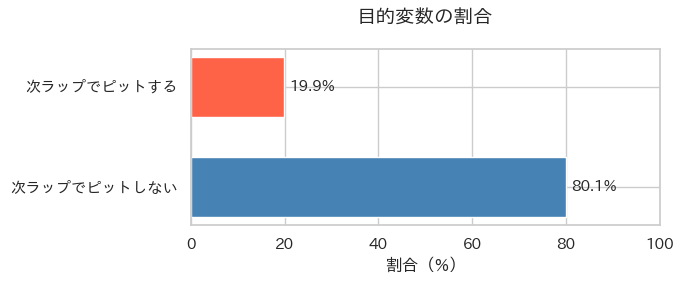

In [ ]:
# 5-1) 目的変数の分布確認

vc_ratio = train[target].value_counts(normalize=True).reindex(class_order) * 100
vc_ratio_jp = vc_ratio.copy()
vc_ratio_jp.index = vc_ratio_jp.index.map(label_map)

fig, ax = plt.subplots(figsize=(7, 3))

bars = ax.barh(
    vc_ratio_jp.index,
    vc_ratio_jp.values,
    height=0.6,
    color=["steelblue", "tomato"]
)

ax.set_title("目的変数の割合", fontsize=14, pad=18)
ax.set_xlabel("割合（%）")
ax.set_xlim(0, 100)

for bar in bars:
    ratio = bar.get_width()

    ax.text(
        ratio + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{ratio:.1f}%",
        va="center",
        ha="left",
        fontsize=11
    )

plt.tight_layout()
plt.show()

5-1) 目的変数の分布確認

確認結果

*   「次ラップでピットしない」が約80.1%、「次ラップでピットする」が約19.9%
*   ピットしないデータが大半を占める不均衡データである
*   ただし極端な不均衡（95:5など）ではなく、ROC AUC評価では対応可能な水準
*   実際のF1レースでも毎周ピットするわけではなく、レース実態に近い分布と考えられる

【表1】数値特徴量の基本統計量


,列名,日本語名,件数,平均,標準偏差,最小値,25%,中央値,75%,最大値
0,LapNumber,現在のラップ数,439140.0,23.105909,16.958261,1.000000,9.00000,19.000000,36.000000,78.000
1,TyreLife,タイヤ使用周回数,439140.0,14.158231,9.801338,1.000000,6.00000,12.000000,20.000000,77.000
2,Position,現在順位,439140.0,9.630339,5.278770,1.000000,5.00000,10.000000,14.000000,20.000
3,Position_Change,順位変動,439140.0,0.101542,4.006765,-18.000000,-1.00000,0.000000,2.000000,18.000
4,LapTime (s),ラップタイム（秒）,439140.0,90.948735,19.772769,67.694000,82.62100,90.521000,98.471000,2507.607
5,LapTime_Delta,前ラップ比ラップタイム差,439140.0,-3.770040,43.945759,-2403.895000,-8.88400,-0.295000,0.115000,2423.932
6,Cumulative_Degradation,累積タイヤ劣化,439140.0,-25.721759,54.766573,-274.564000,-46.56625,-20.994000,-6.199000,2412.026
7,RaceProgress,レース進行率,439140.0,0.337661,0.253277,0.012821,0.12987,0.269231,0.513158,1.000


【表2】IQRによる外れ値確認


,列名,日本語名,下限,上限,外れ値件数,外れ値率_%,最小値,最大値
0,LapNumber,現在のラップ数,-31.500000,76.500000,16,0.00,1.000000,78.000
1,TyreLife,タイヤ使用周回数,-15.000000,41.000000,5711,1.30,1.000000,77.000
2,Position,現在順位,-8.500000,27.500000,0,0.00,1.000000,20.000
3,Position_Change,順位変動,-5.500000,6.500000,61180,13.93,-18.000000,18.000
4,LapTime (s),ラップタイム（秒）,58.846000,122.246000,5905,1.34,67.694000,2507.607
5,LapTime_Delta,前ラップ比ラップタイム差,-22.382500,13.613500,58900,13.41,-2403.895000,2423.932
6,Cumulative_Degradation,累積タイヤ劣化,-107.117125,54.351875,49869,11.36,-274.564000,2412.026
7,RaceProgress,レース進行率,-0.445062,1.088090,0,0.00,0.012821,1.000


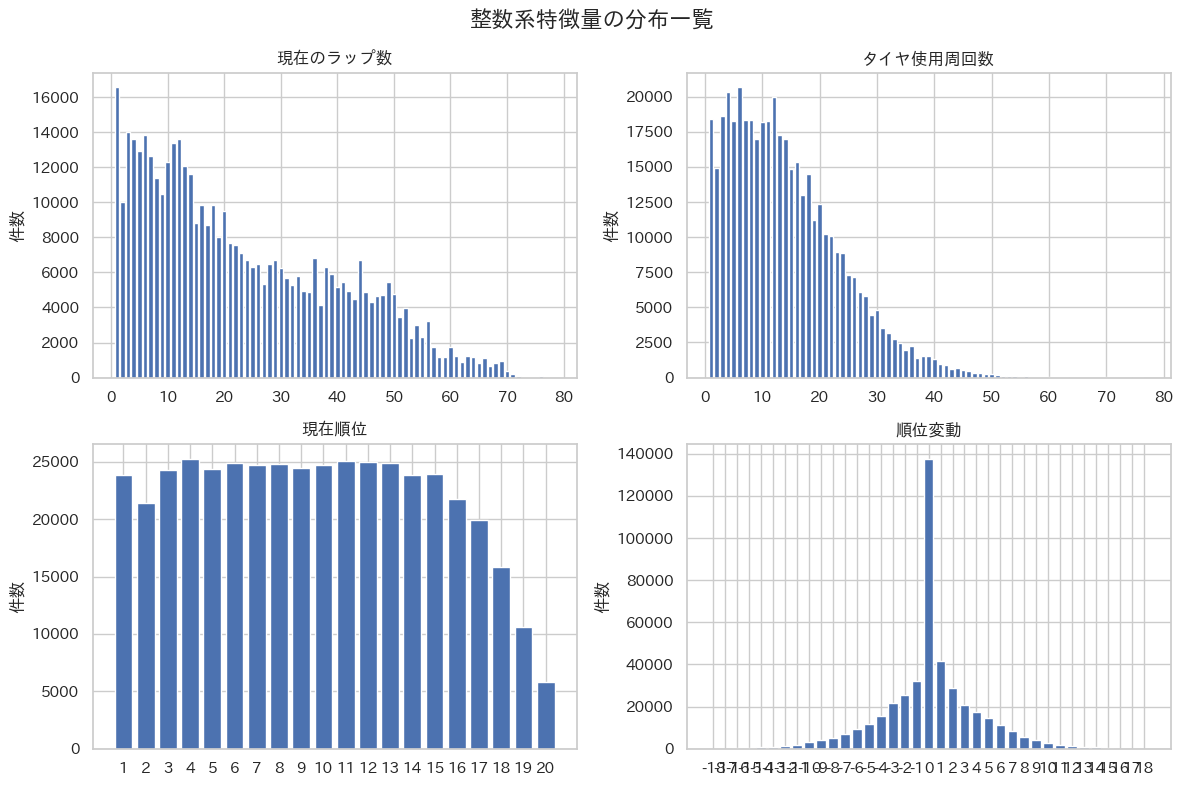

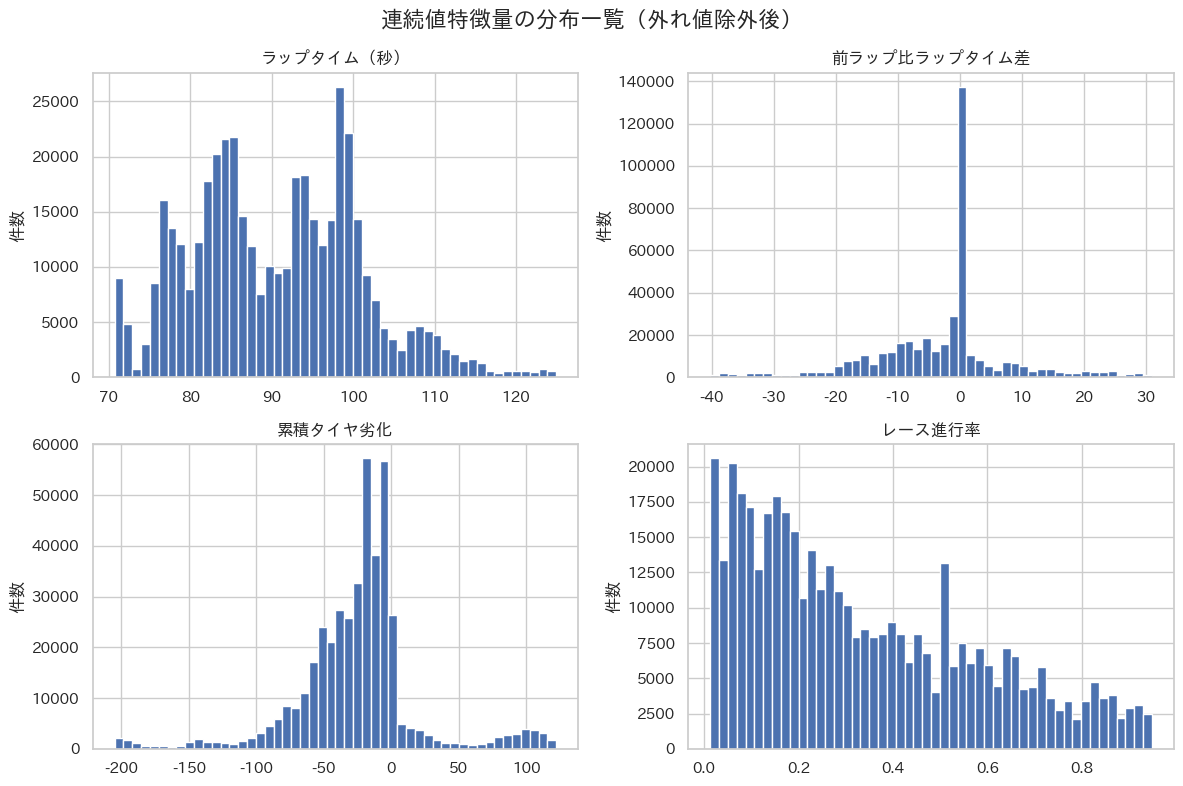

In [ ]:
# 5-2-1) 数値特徴量の分布・外れ値確認

# 整数系特徴量
discrete_cols = [
    "LapNumber",
    "TyreLife",
    "Position",
    "Position_Change"
]

# 連続値特徴量
continuous_cols = [
    "LapTime (s)",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "RaceProgress"
]

# 確認対象列
numeric_check_cols = discrete_cols + continuous_cols

# =========================================================
# 5-2-1-1) 基本統計量
# =========================================================

basic_stats = (
    train[numeric_check_cols]
    .describe()
    .T
    .rename(columns={
        "count": "件数",
        "mean": "平均",
        "std": "標準偏差",
        "min": "最小値",
        "25%": "25%",
        "50%": "中央値",
        "75%": "75%",
        "max": "最大値"
    })
)

basic_stats.insert(0, "列名", basic_stats.index)
basic_stats.insert(1, "日本語名", [jp(c) for c in basic_stats["列名"]])

basic_stats = basic_stats.reset_index(drop=True)

print("【表1】数値特徴量の基本統計量")
display(basic_stats)

# =========================================================
# 5-2-1-2) IQRによる外れ値確認
# =========================================================

outlier_summary = []

for col in numeric_check_cols:

    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = (
        (train[col] < lower) |
        (train[col] > upper)
    ).sum()

    outlier_rate = (
        outlier_count / len(train) * 100
    )

    outlier_summary.append({
        "列名": col,
        "日本語名": jp(col),
        "下限": lower,
        "上限": upper,
        "外れ値件数": outlier_count,
        "外れ値率_%": round(outlier_rate, 2),
        "最小値": train[col].min(),
        "最大値": train[col].max()
    })

outlier_summary = (
    pd.DataFrame(outlier_summary)
    .reset_index(drop=True)
)

print("【表2】IQRによる外れ値確認")
display(outlier_summary)

# =========================================================
# 5-2-1-3) 整数系特徴量の分布確認
# =========================================================

n_cols = 2
n_rows = math.ceil(len(discrete_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 8)
)

axes = axes.flatten()

for ax, col in zip(axes, discrete_cols):

    vc = (
        train[col]
        .value_counts()
        .sort_index()
    )

    ax.bar(
        vc.index,
        vc.values
    )

    ax.set_title(jp(col))
    ax.set_xlabel("")
    ax.set_ylabel("件数")

    # 整数軸にする
    if col in ["Position", "Position_Change"]:
        ax.set_xticks(sorted(vc.index))

# 余ったsubplot削除
for ax in axes[len(discrete_cols):]:
    fig.delaxes(ax)

plt.suptitle("整数系特徴量の分布一覧", fontsize=16)

plt.tight_layout()
plt.show()

# =========================================================
# 5-2-1-4) 連続値特徴量の分布確認
# =========================================================

n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 8)
)

axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):

    # 外れ値の影響を抑えるため1%〜99%範囲で表示
    lower = train[col].quantile(0.01)
    upper = train[col].quantile(0.99)

    data = train[
        (train[col] >= lower) &
        (train[col] <= upper)
    ][col]

    ax.hist(
        data,
        bins=50
    )

    ax.set_title(jp(col))
    ax.set_xlabel("")
    ax.set_ylabel("件数")

# 余ったsubplot削除
for ax in axes[len(continuous_cols):]:
    fig.delaxes(ax)

plt.suptitle(
    "連続値特徴量の分布一覧（外れ値除外後）",
    fontsize=16
)

plt.tight_layout()
plt.show()

5-2-1) 数値特徴量の分布・外れ値確認（「値の分布」と「極端値」を見る）

*   見ているもの：数値特徴量がどの範囲にどれくらい存在するか
*   グラフ：棒グラフ、ヒストグラム
*   確認ポイント：
    *   分布形状
    *   偏り
    *   外れ値
    *   値の範囲
    *   スケール差
    *   一部に集中していないか

確認結果
*   現在のラップ数、タイヤ使用周回数は序盤・短い周回に多く、後半ほど件数が減少している
*   現在順位は1～15位付近まで比較的均等に分布している
*   順位変動は0付近に集中しており、大きな順位変動は一部に限られる
*   ラップタイム、前ラップ比ラップタイム差、累積タイヤ劣化には極端な値が確認された
*   特に Position_Change、LapTime_Delta、Cumulative_Degradation は外れ値率が10%以上と高い
*   レース中の急な順位変動やタイム変化を含む可能性があり、単純な外れ値削除は慎重に判断する必要がある
*   特徴量ごとに値の範囲やスケール差が存在する
*   可視化では外れ値の影響を抑えるため、連続値は1%～99%範囲で確認した

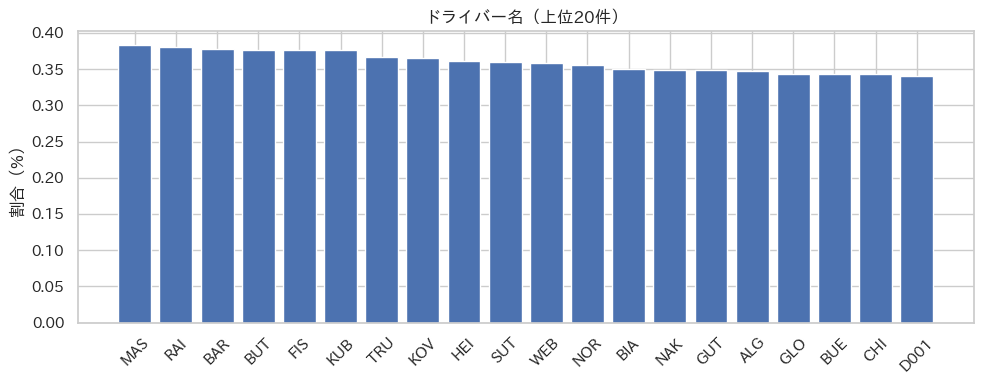

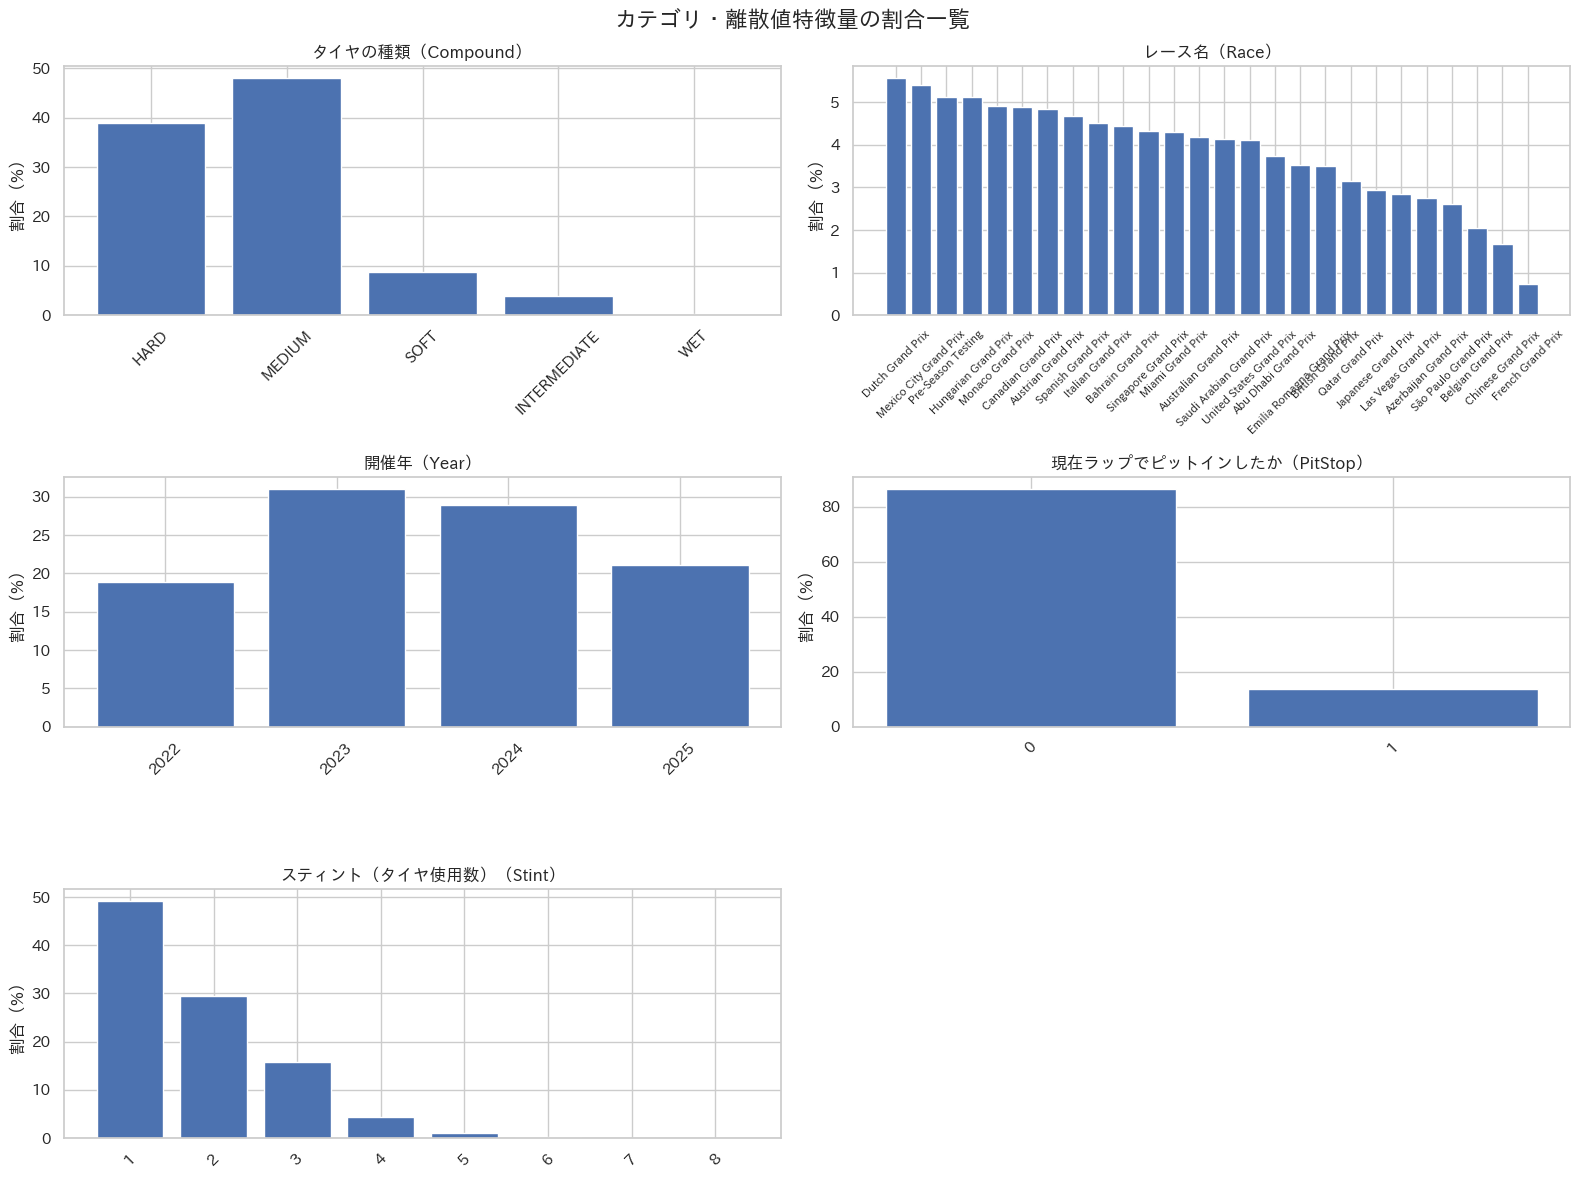

In [ ]:
# 5-2-2) カテゴリ・離散値特徴量の割合確認

# カテゴリとして確認する列
category_check_cols = [
    "Compound",
    "Race",
    "Year",
    "PitStop",
    "Stint"
]

# Driverは別扱い
driver_col = "Driver"

# ---------------------------------------------------------
# 5-2-2-1) Driver（上位20件）
# ---------------------------------------------------------

driver_vc = (
    train[driver_col]
    .value_counts(normalize=True)
    .head(20)
    .mul(100)
)

plt.figure(figsize=(10, 4))

plt.bar(
    driver_vc.index,
    driver_vc.values
)

plt.title("ドライバー名（上位20件）")
plt.ylabel("割合（%）")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5-2-2-2) その他カテゴリ特徴量
# ---------------------------------------------------------

n_cols = 2
n_rows = math.ceil(len(category_check_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows * 4)
)

axes = axes.flatten()

for ax, col in zip(axes, category_check_cols):

    # Compoundは順番固定
    if col == "Compound":

        compound_order = [
            "HARD",
            "MEDIUM",
            "SOFT",
            "INTERMEDIATE",
            "WET"
        ]

        vc = (
            train[col]
            .value_counts(normalize=True)
            .reindex(compound_order)
            .fillna(0)
            .mul(100)
        )

    # Raceは割合順
    elif col == "Race":

        vc = (
            train[col]
            .value_counts(normalize=True)
            .sort_values(ascending=False)
            .mul(100)
        )

    # その他
    else:

        vc = (
            train[col]
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
        )

    ax.bar(
        vc.index.astype(str),
        vc.values
    )

    ax.set_title(f"{jp(col)}（{col}）")
    ax.set_xlabel("")
    ax.set_ylabel("割合（%）")

    # x軸ラベル調整
    if col == "Race":
        ax.tick_params(axis="x", rotation=45, labelsize=8)
    else:
        ax.tick_params(axis="x", rotation=45)

# 余ったsubplot削除
for ax in axes[len(category_check_cols):]:
    fig.delaxes(ax)

plt.suptitle(
    "カテゴリ・離散値特徴量の割合一覧",
    fontsize=16
)

plt.tight_layout()
plt.show()

  5-2-2) カテゴリ特徴量の割合一覧（「カテゴリの割合」を見る）
*   見ているもの：各カテゴリ・離散値がどれくらい存在するか
*   グラフ：棒グラフ（割合）
*   確認ポイント：
    *   カテゴリの偏り
    *   少数カテゴリ
    *   極端に多いカテゴリ
    *   train/testでズレてないか
    *   特定カテゴリだけ極端に多くないか

確認結果
*   タイヤ種類は MEDIUM と HARD が多く、WET はほとんど存在しない
*   開催年は2023・2024が比較的多いが、大きな偏りではない
*   現在ラップでピットインしたか（PitStop）は「0」が大半を占める
*   スティント（タイヤ使用数）は1～3が中心で、4以上は少数
*   レース名ごとの割合は大きく偏っておらず、比較的均等に分布している
*   ドライバー名（上位20件）も大きな偏りは見られない
*   一部少数カテゴリは存在するが、カテゴリ特徴量はそのまま学習に利用可能と考えられる

【表3】目的変数別平均


,現在のラップ数,タイヤ使用周回数,前ラップ比ラップタイム差,累積タイヤ劣化,レース進行率,スティント（タイヤ使用数）
次ラップでピットしない,20.848706,12.822114,-3.661698,-21.152364,0.314247,1.695252
次ラップでピットする,32.192456,19.536873,-4.206182,-44.116212,0.431914,2.166958


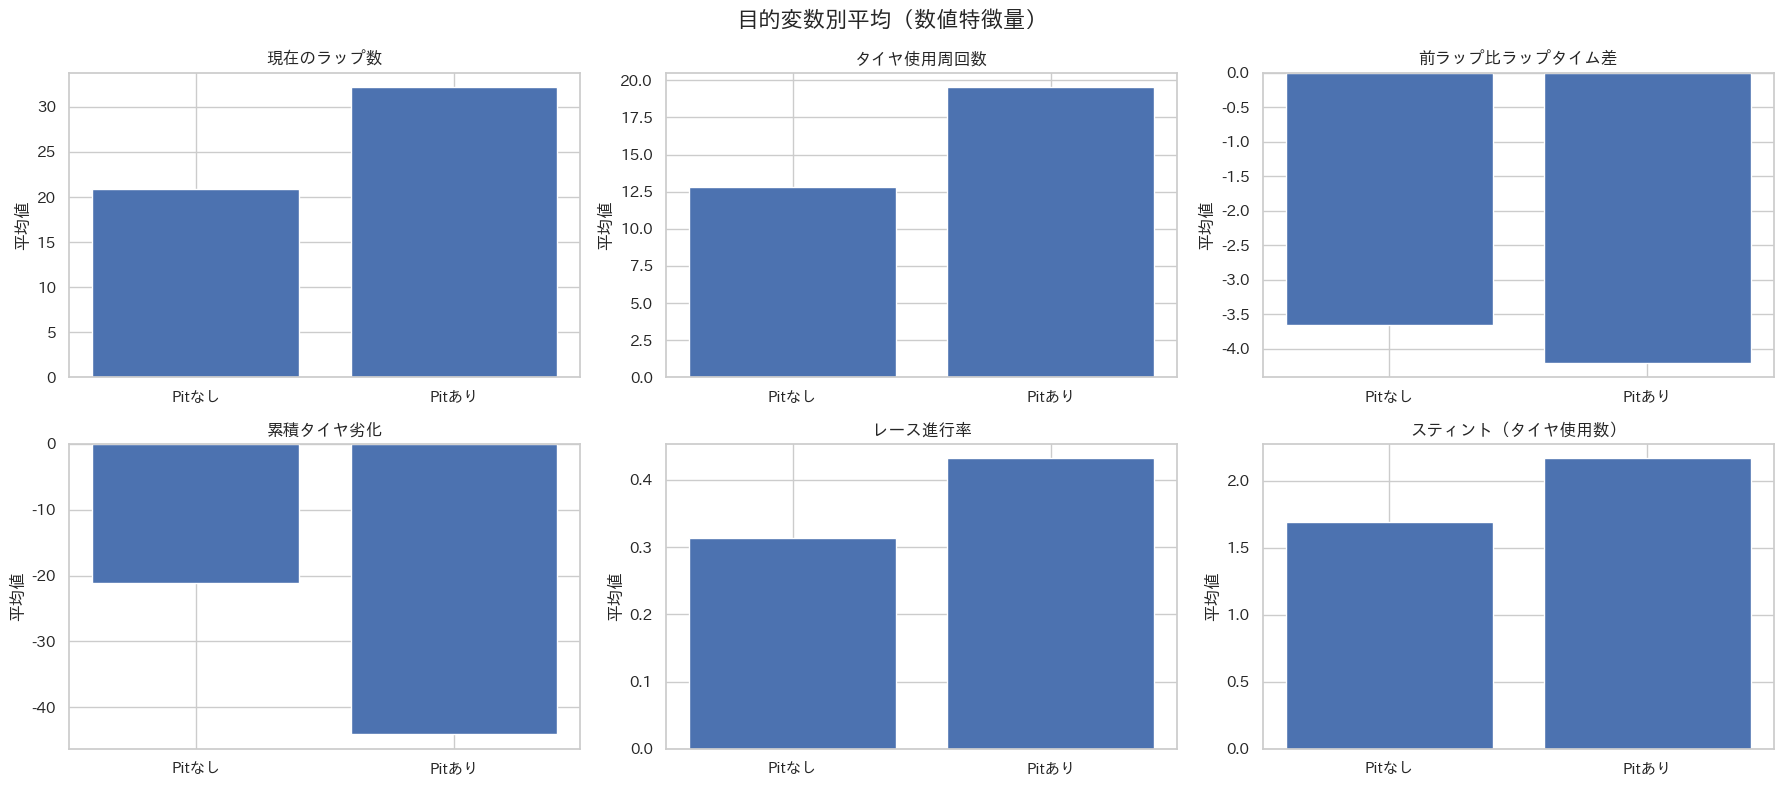

In [ ]:
# 5-3-1) 目的変数別平均（数値特徴量）

# 確認対象列
mean_check_cols = [
    "LapNumber",
    "TyreLife",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "RaceProgress",
    "Stint"
]

# 表示順
target_order = [0, 1]

# ---------------------------------------------------------
# 表形式
# ---------------------------------------------------------

target_mean = (
    train
    .groupby(target)[mean_check_cols]
    .mean()
    .reindex(target_order)
)

target_mean.index = [
    "次ラップでピットしない",
    "次ラップでピットする"
]

target_mean_jp = target_mean.copy()

target_mean_jp.columns = [
    jp(c)
    for c in target_mean_jp.columns
]

print("【表3】目的変数別平均")

display(target_mean_jp)

# ---------------------------------------------------------
# グラフ表示
# ---------------------------------------------------------

n_cols = 3
n_rows = math.ceil(len(mean_check_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for ax, col in zip(axes, mean_check_cols):

    mean_values = (
        train
        .groupby(target)[col]
        .mean()
        .reindex(target_order)
    )

    ax.bar(
        ["Pitなし", "Pitあり"],
        mean_values.values
    )

    ax.set_title(f"{jp(col)}")
    ax.set_ylabel("平均値")

# 余り削除
for ax in axes[len(mean_check_cols):]:
    fig.delaxes(ax)

plt.suptitle(
    "目的変数別平均（数値特徴量）",
    fontsize=16
)

plt.tight_layout()
plt.show()

5-3-1) 目的変数別平均（数値特徴量）
*   目的：数値特徴量ごとに、Pitあり / Pitなしで平均値が違うか確認する
*   見ていること：
    *   どの特徴量でクラス差が大きいか
    *   ピット判断と関係がありそうか
*   役割：数値特徴量の「傾向差」を把握する

確認結果
*   Pitありは、Pitなしより現在のラップ数が大きい
*   Pitありは、タイヤ使用周回数が長い
*   Pitありは、レース進行率が高く、よりレース後半寄りで発生している
*   Pitありは、スティント数が高く、戦略段階が進んでいる傾向がある
*   Pitありは、累積タイヤ劣化がより大きくマイナス方向に出ている
*   これらより、ピット判断は「タイヤ使用周回数」「レース進行度」「累積劣化」「戦略段階」と関係がありそうと考えられる


【タイヤの種類（Compound） × 目的変数】


,Pitなし,Pitあり
Compound,,
HARD,0.672,0.328
INTERMEDIATE,0.848,0.152
MEDIUM,0.899,0.101
SOFT,0.807,0.193
WET,0.975,0.025


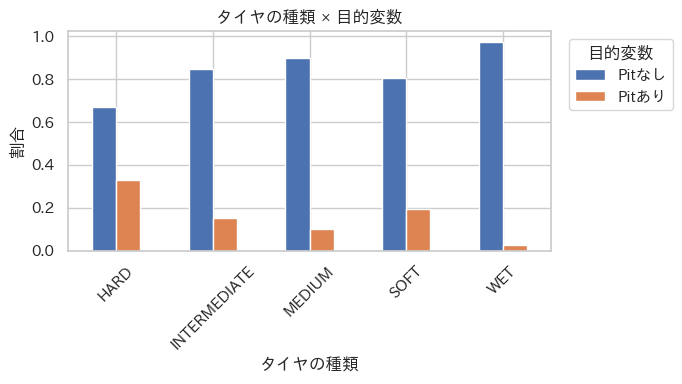


【開催年（Year） × 目的変数】


,Pitなし,Pitあり
Year,,
2022,0.733,0.267
2023,0.990,0.010
2024,0.705,0.295
2025,0.716,0.284


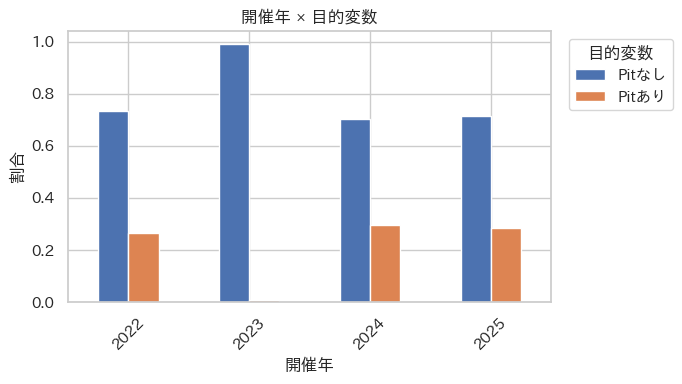


【現在ラップでピットインしたか（PitStop） × 目的変数】


,Pitなし,Pitあり
PitStop,,
0,0.809,0.191
1,0.752,0.248


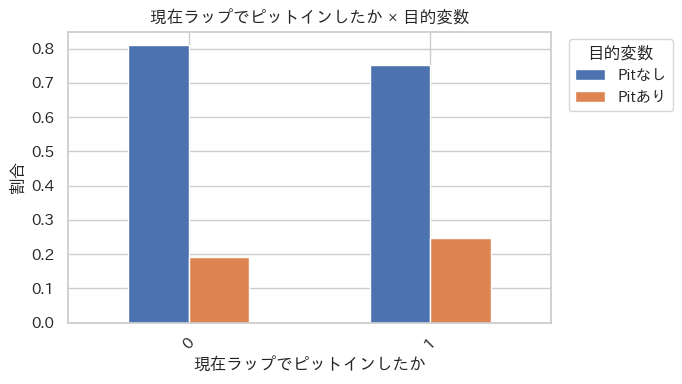


【スティント（タイヤ使用数）（Stint） × 目的変数】


,Pitなし,Pitあり
Stint,,
1,0.940,0.060
2,0.609,0.391
3,0.707,0.293
4,0.828,0.172
5,0.947,0.053
6,0.981,0.019
7,1.000,0.000
8,0.980,0.020


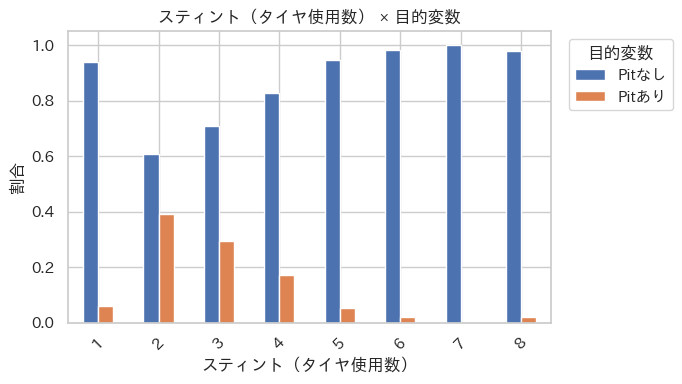


【レース名（上位10件） × 目的変数】


,Pitなし,Pitあり
Race,,
Austrian Grand Prix,0.812,0.188
Bahrain Grand Prix,0.712,0.288
Canadian Grand Prix,0.846,0.154
Dutch Grand Prix,0.824,0.176
Hungarian Grand Prix,0.761,0.239
Italian Grand Prix,0.868,0.132
Mexico City Grand Prix,0.909,0.091
Monaco Grand Prix,0.643,0.357
Pre-Season Testing,0.853,0.147


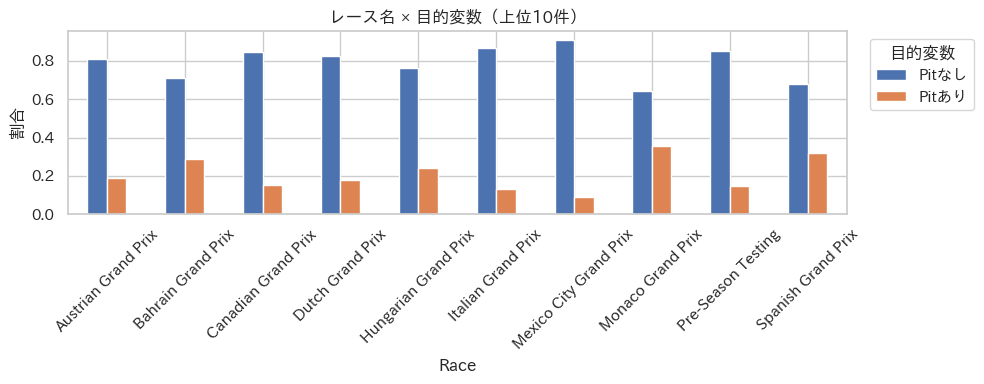

In [ ]:
# =========================================================
# 5-3-2) カテゴリ特徴量 × 目的変数
# =========================================================

# 確認対象
cat_target_cols = [
    "Compound",
    "Year",
    "PitStop",
    "Stint"
]

for col in cat_target_cols:

    print(f"\n【{jp(col)}（{col}） × 目的変数】")

    # 行方向割合
    ctab = pd.crosstab(
        train[col],
        train[target],
        normalize="index"
    ).round(3)

    # Compoundは順番固定
    if col == "Compound":

        compound_order = [
            "HARD",
            "MEDIUM",
            "SOFT",
            "INTERMEDIATE",
            "WET"
        ]

        ctab = ctab.reindex(compound_order)

    # 列名変更
    ctab.columns = [
        "Pitなし",
        "Pitあり"
    ]

    display(ctab)

    # グラフ
    ax = ctab.plot(
        kind="bar",
        figsize=(7, 4)
    )

    ax.set_title(f"{jp(col)} × 目的変数")
    ax.set_xlabel(jp(col))
    ax.set_ylabel("割合")

    plt.xticks(rotation=45)

    ax.legend(
        title="目的変数",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

# =========================================================
# Race（上位10件のみ）
# =========================================================

top_races = (
    train["Race"]
    .value_counts()
    .head(10)
    .index
)

race_train = train[
    train["Race"].isin(top_races)
]

print("\n【レース名（上位10件） × 目的変数】")

race_ctab = pd.crosstab(
    race_train["Race"],
    race_train[target],
    normalize="index"
).round(3)

race_ctab.columns = [
    "Pitなし",
    "Pitあり"
]

display(race_ctab)

ax = race_ctab.plot(
    kind="bar",
    figsize=(10, 4)
)

ax.set_title("レース名 × 目的変数（上位10件）")
ax.set_xlabel("Race")
ax.set_ylabel("割合")

plt.xticks(rotation=45)

ax.legend(
    title="目的変数",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

5-3-2) カテゴリ × target
*   目的：カテゴリごとの Pitあり / Pitなし の割合差を確認する
*   見ていること：
    *   どのカテゴリで Pitあり が多いか
    *   どのカテゴリで Pitなし が多いか
    *   カテゴリごとの差が存在するか
*   役割：カテゴリ特徴量と目的変数の関係を確認する

確認結果

*   タイヤ種類では HARD が最も Pitあり割合が高く、MEDIUM は低い傾向が見られる
*   WET はほとんど Pitあり が発生していない
*   開催年では2023のみ Pitあり割合が極端に低く、他年度と分布差が見られる
*   現在ラップでピットインした場合（PitStop=1）は、次ラップでも Pitあり となる割合がやや高い
*   スティントでは2～3スティント目で Pitあり割合が高く、1スティント目や後半スティントでは低い
*   レース名ごとにも差があり、Monaco Grand Prix や Spanish Grand Prix は Pitあり割合が比較的高い
*   一方、Mexico City Grand Prix や Italian Grand Prix は Pitあり割合が低い
*   カテゴリごとに目的変数割合の差が見られ、戦略・サーキット特性との関係が示唆される

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 87381, number of negative: 351759
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1804
[LightGBM] [Info] Number of data points in the train set: 439140, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198982 -> initscore=-1.392668
[LightGBM] [Info] Start training from score -1.392668
【表4】特徴量重要度


,feature,日本語名,importance
0,Driver,ドライバー名,1303
2,Race,レース名,425
7,TyreLife,タイヤ使用周回数,274
12,RaceProgress,レース進行率,189
6,Stint,スティント（タイヤ使用数）,168
10,LapTime_Delta,前ラップ比ラップタイム差,156
3,Year,開催年,140
13,Position_Change,順位変動,84
11,Cumulative_Degradation,累積タイヤ劣化,59
5,LapNumber,現在のラップ数,58


上位数値特徴量: ['TyreLife', 'RaceProgress', 'LapTime_Delta', 'Position_Change', 'Cumulative_Degradation']


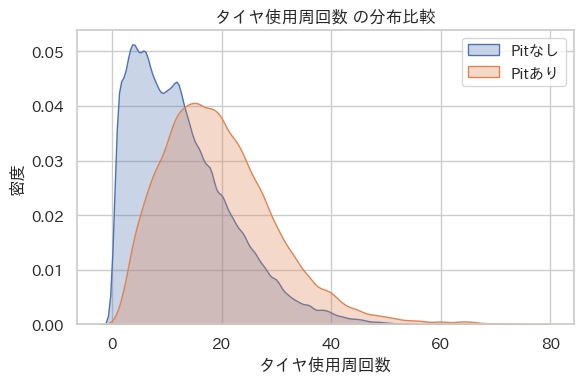

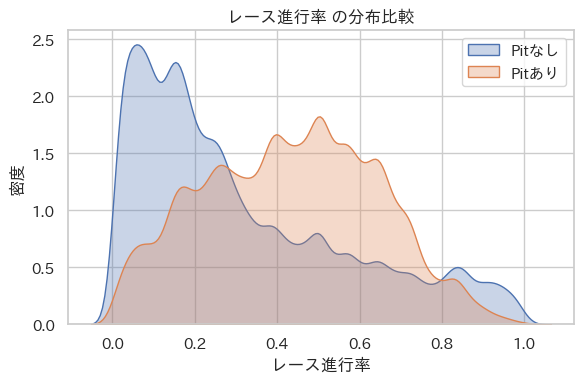

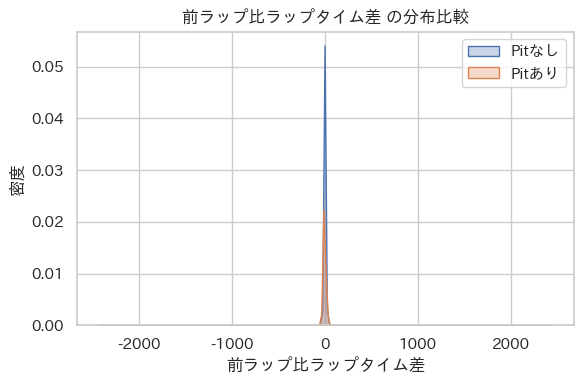

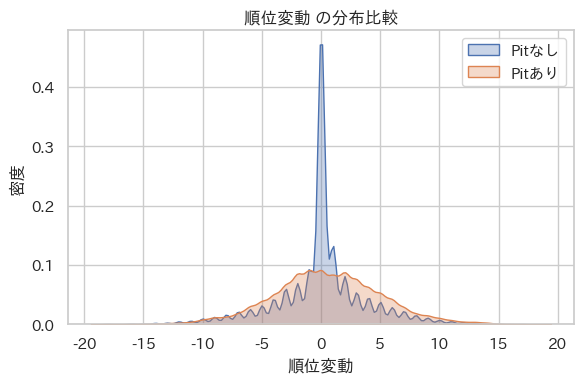

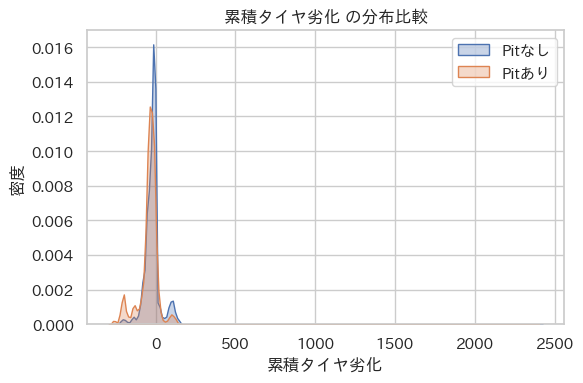

In [ ]:
# 5-3-3) 上位特徴量分布比較

try:
    import lightgbm as lgb
except ImportError:
    !pip -q install lightgbm
    import lightgbm as lgb

# ---------------------------------------------------------
# 仮モデル作成
# ---------------------------------------------------------

X = train[features].copy()
y = train[target]

# カテゴリ型変換
for col in cat_cols:
    X[col] = X[col].astype("category")

# 仮LightGBM
model_tmp = lgb.LGBMClassifier(
    objective="binary",
    random_state=42
)

model_tmp.fit(X, y)

# ---------------------------------------------------------
# 特徴量重要度
# ---------------------------------------------------------

importance = (
    pd.DataFrame({
        "feature": X.columns,
        "日本語名": [jp(c) for c in X.columns],
        "importance": model_tmp.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print("【表4】特徴量重要度")

display(importance.head(10))

# ---------------------------------------------------------
# 上位数値特徴量抽出
# ---------------------------------------------------------

top_num_cols = [
    c for c in importance["feature"]
    if c in numeric_check_cols
][:5]

print("上位数値特徴量:", top_num_cols)

# ---------------------------------------------------------
# 分布比較
# ---------------------------------------------------------

for col in top_num_cols:

    plt.figure(figsize=(6, 4))

    # Pitなし
    sns.kdeplot(
        train.loc[train[target] == 0, col],
        label="Pitなし",
        fill=True,
        alpha=0.3
    )

    # Pitあり
    sns.kdeplot(
        train.loc[train[target] == 1, col],
        label="Pitあり",
        fill=True,
        alpha=0.3
    )

    plt.title(f"{jp(col)} の分布比較")
    plt.xlabel(jp(col))
    plt.ylabel("密度")

    plt.legend()

    plt.tight_layout()
    plt.show()

5-3-3) 上位特徴量分布
*   目的：LightGBM重要度で上位だった数値特徴量の分布差を詳しく確認する
*   流れ：
    1.   仮LightGBM feature_importances_で重要度確認
    2.   上位数値特徴量を選定
    3.   KDEで Pitあり / Pitなし の分布差を確認
*   見ていること：
    *   分布が分離しているか
    *   Pitあり / Pitなし の差が大きいか
    *   モデルが使いやすそうか
*   役割：重要特徴量の「分布差」を詳しく確認する

確認結果
*   LightGBM重要度では、ドライバー名、レース名、タイヤ使用周回数、レース進行率、スティントが上位特徴量となった
*   数値特徴量では、タイヤ使用周回数、レース進行率、前ラップ比ラップタイム差、順位変動、累積タイヤ劣化を重点確認した
*   タイヤ使用周回数は、Pitあり が長い周回側に分布しており、タイヤ使用が進むほどピットしやすい傾向が見られる
*   レース進行率は、Pitあり が中盤～後半側に多く分布している
*   順位変動は、Pitなし が0付近に集中している一方、Pitあり は分布が広く、順位変化と戦略変更の関係が示唆される
*   累積タイヤ劣化は、Pitあり の方がより劣化側に分布している
*   前ラップ比ラップタイム差は分布差が比較的小さく、単独での分離は弱い
*   全体として、タイヤ使用状況・レース進行度・順位変動は、ピット判断に関係する重要特徴量と考えられる

【表5】数値特徴量の相関上位


,特徴量1,特徴量1_日本語名,特徴量2,特徴量2_日本語名,相関係数
6,LapNumber,現在のラップ数,RaceProgress,レース進行率,0.964539
0,LapNumber,現在のラップ数,TyreLife,タイヤ使用周回数,0.648408
12,TyreLife,タイヤ使用周回数,RaceProgress,レース進行率,0.622660
13,Position,現在順位,Position_Change,順位変動,-0.316446
23,LapTime (s),ラップタイム（秒）,Cumulative_Degradation,累積タイヤ劣化,0.205705
5,LapNumber,現在のラップ数,Cumulative_Degradation,累積タイヤ劣化,-0.173135
22,LapTime (s),ラップタイム（秒）,LapTime_Delta,前ラップ比ラップタイム差,0.138818
27,Cumulative_Degradation,累積タイヤ劣化,RaceProgress,レース進行率,-0.137938
9,TyreLife,タイヤ使用周回数,LapTime (s),ラップタイム（秒）,-0.133304
3,LapNumber,現在のラップ数,LapTime (s),ラップタイム（秒）,-0.128485


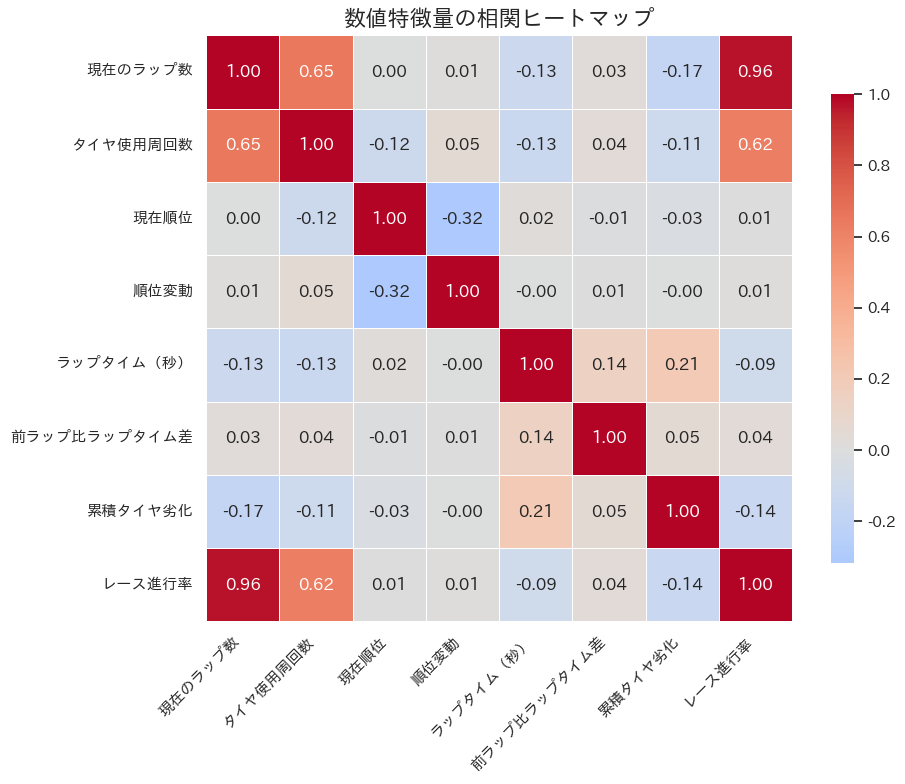

In [ ]:
# 5-4) 数値特徴量の相関確認

# 相関確認対象
corr_cols = numeric_check_cols

# 相関行列
corr = train[corr_cols].corr(numeric_only=True)

# ---------------------------------------------------------
# 相関上位確認
# ---------------------------------------------------------

corr_pairs = (
    corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "特徴量1",
    "特徴量2",
    "相関係数"
]

corr_pairs["相関係数_絶対値"] = corr_pairs["相関係数"].abs()

corr_pairs = corr_pairs.sort_values(
    "相関係数_絶対値",
    ascending=False
)

corr_pairs["特徴量1_日本語名"] = corr_pairs["特徴量1"].map(jp)
corr_pairs["特徴量2_日本語名"] = corr_pairs["特徴量2"].map(jp)

print("【表5】数値特徴量の相関上位")

display(
    corr_pairs[
        [
            "特徴量1",
            "特徴量1_日本語名",
            "特徴量2",
            "特徴量2_日本語名",
            "相関係数"
        ]
    ].head(10)
)

# ---------------------------------------------------------
# 相関ヒートマップ
# ---------------------------------------------------------

corr_jp = corr.copy()

corr_jp.columns = [jp(c) for c in corr.columns]
corr_jp.index = [jp(c) for c in corr.index]

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_jp,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "数値特徴量の相関ヒートマップ",
    fontsize=16
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

5-4) 相関確認
*   目的：数値特徴量同士の関係性を確認する
*   見ていること：
    *   強い相関がある特徴量がないか
    *   同じような情報を持つ特徴量がないか
    *   多重共線性のリスクがないか
*   役割：特徴量同士の重複や関係性を把握する

確認結果
*   最も相関が高かったのは、「現在のラップ数」と「レース進行率」の正の相関（0.96）であり、ほぼ同じ進行状況を表している
*   「現在のラップ数」と「タイヤ使用周回数」も比較的高い正の相関（0.65）が見られる
*   「タイヤ使用周回数」と「レース進行率」にも正の相関（0.62）が確認された
*   「現在順位」と「順位変動」は負の相関（-0.32）が見られ、順位が低いほど順位変動が大きくなる傾向がある
*   それ以外の特徴量間の相関は比較的弱く、強い多重共線性は限定的と考えられる
*   特に「現在のラップ数」と「レース進行率」は情報が近いため、モデル解釈時には注意が必要である

In [ ]:
# 5-5) train/test 基本統計量比較

compare_stats = pd.DataFrame({
    "train_mean": train[numeric_check_cols].mean(),
    "test_mean": test[numeric_check_cols].mean(),
    "train_std": train[numeric_check_cols].std(),
    "test_std": test[numeric_check_cols].std()
})

compare_stats["mean_diff"] = (
    compare_stats["train_mean"] -
    compare_stats["test_mean"]
).abs()

compare_stats.insert(
    0,
    "日本語名",
    [jp(c) for c in compare_stats.index]
)

display(compare_stats.round(3))

,日本語名,train_mean,test_mean,train_std,test_std,mean_diff
LapNumber,現在のラップ数,23.106,23.050,16.958,17.002,0.056
TyreLife,タイヤ使用周回数,14.158,14.161,9.801,9.853,0.002
Position,現在順位,9.630,9.605,5.279,5.273,0.026
Position_Change,順位変動,0.102,0.107,4.007,4.021,0.005
LapTime (s),ラップタイム（秒）,90.949,90.987,19.773,20.855,0.038
LapTime_Delta,前ラップ比ラップタイム差,-3.770,-3.578,43.946,40.348,0.192
Cumulative_Degradation,累積タイヤ劣化,-25.722,-25.849,54.767,54.920,0.128
RaceProgress,レース進行率,0.338,0.337,0.253,0.253,0.001


5-5) train/test比較
*   目的：train と test の基本統計量が大きくズレていないか確認する
*   見ていること：
    *   平均値の差
    *   標準偏差の差
    *   train/test の傾向差
*   役割：学習データと予測対象データの整合性を確認する

確認結果
*   全体として、train と test の平均値・標準偏差は非常に近く、大きな差は見られない
*   現在のラップ数、タイヤ使用周回数、現在順位、レース進行率はほぼ同水準である
*   ラップタイム、累積タイヤ劣化、順位変動についても大きな乖離は確認されない
*   前ラップ比ラップタイム差は標準偏差にやや差が見られるが、平均値差は小さい
*   train/test 間で基本統計量が近いため、学習時と推論時の分布乖離リスクは比較的小さいと考えられる

## 6. 前処理方針

*   今回のデータは、数値特徴量・カテゴリ特徴量を含む大規模な表形式データであり、カテゴリ列を扱いやすく、非線形関係にも対応可能な木モデル（LightGBM）をベースラインモデルとして採用する
*   欠損は存在しないため、欠損補完は行わない
*   目的変数 PitNextLap は 0 / 1 の二値分類問題として扱う
*   id は識別子であり予測に直接利用しないため、特徴量から除外する
*   説明変数は、数値列11列・カテゴリ列3列で構成されているため、カテゴリ列は category 型へ変換し、LightGBMで扱える形にする
*   Driver は高カーディナリティ特徴量（887種類）であり、train のみに存在するカテゴリも確認されたため、カテゴリ処理時に注意する
*   train/test の基本統計量比較では大きな分布差は見られなかったため、特別な分布補正は行わない
*   数値特徴量間では、「現在のラップ数」と「レース進行率」に強い相関（0.96）が確認されたが、木モデルでは影響が比較的小さいため、現時点では削除せず利用する
*   外れ値は一部特徴量（LapTime_Delta、Position_Change、Cumulative_Degradation）で多く確認されたが、レース中の急変動を表している可能性があるため、単純除外は行わない
*   LightGBM は木モデルであり、特徴量スケーリングの影響を受けにくいため、標準化・正規化は行わない
*   目的変数は二値分類であり、回帰問題で用いられるような log 変換は基本的に行わない
*   クラス分布では「Pitあり」が約20%とやや少ない不均衡データであるため、必要に応じて class_weight や閾値調整を検討する
*   まずは最小限の前処理でベースラインモデルを構築し、その後、特徴量エンジニアリングやハイパーパラメータ調整による改善を検討する

## 7. モデル確認

In [ ]:
# =========================
# 7-0) 共通設定
# =========================

try:
    import lightgbm as lgb
except ImportError:
    !pip -q install lightgbm
    import lightgbm as lgb

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score


In [ ]:
# =========================
# 7-1) 学習データ作成（id除外）
# =========================

drop_cols = ["id", target]

X = train.drop(columns=[c for c in drop_cols if c in train.columns])
X_test = test.drop(columns=[c for c in ["id"] if c in test.columns])

y = train[target].astype(int)

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("y shape:", y.shape)

# カテゴリ列
cat_cols_model = X.select_dtypes(include="object").columns.tolist()
print("categorical cols:", cat_cols_model)

# category型に変換
for c in cat_cols_model:
    X[c] = X[c].astype("category")
    X_test[c] = X_test[c].astype("category")

X shape: (439140, 17)
X_test shape: (188165, 17)
y shape: (439140,)
categorical cols: ['Driver', 'Compound', 'Race']


In [ ]:
# =========================
# 7-2) LightGBM ベースラインCV
# =========================

params = {
    "objective": "binary",
    "learning_rate": 0.05,
    "n_estimators": 2000,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("\n===== 7-2 LightGBM ベースラインCV =====")

oof_pred = np.zeros(len(X))
test_pred = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = lgb.LGBMClassifier(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="auc",
        categorical_feature=cat_cols_model,
        callbacks=[
            lgb.early_stopping(100, verbose=False)
        ]
    )

    va_pred = model.predict_proba(X_va)[:, 1]
    oof_pred[va_idx] = va_pred

    test_pred += model.predict_proba(X_test)[:, 1] / skf.n_splits

    fold_score = roc_auc_score(y_va, va_pred)

    print(f"fold{fold} AUC: {fold_score:.5f}")

cv_score = roc_auc_score(y, oof_pred)

print("\nCV AUC:", round(cv_score, 5))


===== 7-2 LightGBM ベースラインCV =====
fold1 AUC: 0.94365
fold2 AUC: 0.94191
fold3 AUC: 0.94268
fold4 AUC: 0.94180
fold5 AUC: 0.94345

CV AUC: 0.9427


In [ ]:
# =========================
# 7-3) 改善：軽いパラメータ調整
# =========================

print("\n===== 7-3 軽いパラメータ調整 =====")

params_tuned = {
    "objective": "binary",
    "learning_rate": 0.03,
    "n_estimators": 3000,
    "num_leaves": 63,
    "min_child_samples": 50,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

oof_pred_tuned = np.zeros(len(X))
test_pred_tuned = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = lgb.LGBMClassifier(**params_tuned)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="auc",
        categorical_feature=cat_cols_model,
        callbacks=[
            lgb.early_stopping(100, verbose=False)
        ]
    )

    va_pred = model.predict_proba(X_va)[:, 1]
    oof_pred_tuned[va_idx] = va_pred

    test_pred_tuned += model.predict_proba(X_test)[:, 1] / skf.n_splits

    fold_score = roc_auc_score(y_va, va_pred)

    print(f"fold{fold} AUC: {fold_score:.5f}")

cv_score_tuned = roc_auc_score(y, oof_pred_tuned)

print("\nCV AUC tuned:", round(cv_score_tuned, 5))


===== 7-3 軽いパラメータ調整 =====
fold1 AUC: 0.94280
fold2 AUC: 0.94138
fold3 AUC: 0.94218
fold4 AUC: 0.94105
fold5 AUC: 0.94299

CV AUC tuned: 0.94207


In [ ]:
# =========================
# 7-4) 改善：Seed平均
# =========================

print("\n===== 7-4 Seed平均 =====")

seeds = [
    42,
    2024,
    2025
]

params_seed = {
    "objective": "binary",
    "learning_rate": 0.05,
    "n_estimators": 2000,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_jobs": -1,
    "verbosity": -1,
}

oof_pred_seed = np.zeros(len(X))
test_pred_seed = np.zeros(len(X_test))

total_models = 0

for seed in seeds:

    print(f"\n--- seed: {seed} ---")

    skf_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_pred_one_seed = np.zeros(len(X))
    test_pred_one_seed = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf_seed.split(X, y), 1):

        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = lgb.LGBMClassifier(
            **params_seed,
            random_state=seed
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            categorical_feature=cat_cols_model,
            callbacks=[
                lgb.early_stopping(100, verbose=False)
            ]
        )

        va_pred = model.predict_proba(X_va)[:, 1]
        test_pred_one_seed += model.predict_proba(X_test)[:, 1] / skf_seed.n_splits

        oof_pred_one_seed[va_idx] = va_pred

        fold_score = roc_auc_score(y_va, va_pred)

        print(f"seed{seed} fold{fold} AUC: {fold_score:.5f}")

    seed_score = roc_auc_score(y, oof_pred_one_seed)

    print(f"seed{seed} CV AUC: {seed_score:.5f}")

    oof_pred_seed += oof_pred_one_seed / len(seeds)
    test_pred_seed += test_pred_one_seed / len(seeds)

    total_models += skf_seed.n_splits

cv_score_seed = roc_auc_score(y, oof_pred_seed)

print("\nCV AUC seed average:", round(cv_score_seed, 5))
print("total models:", total_models)


===== 7-4 Seed平均 =====

--- seed: 42 ---
seed42 fold1 AUC: 0.94365
seed42 fold2 AUC: 0.94191
seed42 fold3 AUC: 0.94268
seed42 fold4 AUC: 0.94180
seed42 fold5 AUC: 0.94345
seed42 CV AUC: 0.94270

--- seed: 2024 ---
seed2024 fold1 AUC: 0.94377
seed2024 fold2 AUC: 0.94307
seed2024 fold3 AUC: 0.94206
seed2024 fold4 AUC: 0.94231
seed2024 fold5 AUC: 0.94165
seed2024 CV AUC: 0.94257

--- seed: 2025 ---
seed2025 fold1 AUC: 0.94321
seed2025 fold2 AUC: 0.94334
seed2025 fold3 AUC: 0.94155
seed2025 fold4 AUC: 0.94314
seed2025 fold5 AUC: 0.94181
seed2025 CV AUC: 0.94260

CV AUC seed average: 0.94364
total models: 15


In [ ]:
# =========================
# 7-4) 改善：Seed平均_特徴量追加①後
# =========================

print("\n===== 7-4 Seed平均 =====")

seeds = [
    42,
    2024,
    2025
]

params_seed = {
    "objective": "binary",
    "learning_rate": 0.05,
    "n_estimators": 2000,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_jobs": -1,
    "verbosity": -1,
}

oof_pred_seed = np.zeros(len(X))
test_pred_seed = np.zeros(len(X_test))

total_models = 0

for seed in seeds:

    print(f"\n--- seed: {seed} ---")

    skf_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_pred_one_seed = np.zeros(len(X))
    test_pred_one_seed = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf_seed.split(X, y), 1):

        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = lgb.LGBMClassifier(
            **params_seed,
            random_state=seed
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            categorical_feature=cat_cols_model,
            callbacks=[
                lgb.early_stopping(100, verbose=False)
            ]
        )

        va_pred = model.predict_proba(X_va)[:, 1]
        test_pred_one_seed += model.predict_proba(X_test)[:, 1] / skf_seed.n_splits

        oof_pred_one_seed[va_idx] = va_pred

        fold_score = roc_auc_score(y_va, va_pred)

        print(f"seed{seed} fold{fold} AUC: {fold_score:.5f}")

    seed_score = roc_auc_score(y, oof_pred_one_seed)

    print(f"seed{seed} CV AUC: {seed_score:.5f}")

    oof_pred_seed += oof_pred_one_seed / len(seeds)
    test_pred_seed += test_pred_one_seed / len(seeds)

    total_models += skf_seed.n_splits

cv_score_seed = roc_auc_score(y, oof_pred_seed)

print("\nCV AUC seed average:", round(cv_score_seed, 5))
print("total models:", total_models)


===== 7-4 Seed平均 =====

--- seed: 42 ---
seed42 fold1 AUC: 0.94455
seed42 fold2 AUC: 0.94297
seed42 fold3 AUC: 0.94388
seed42 fold4 AUC: 0.94295
seed42 fold5 AUC: 0.94459
seed42 CV AUC: 0.94378

--- seed: 2024 ---
seed2024 fold1 AUC: 0.94433
seed2024 fold2 AUC: 0.94325
seed2024 fold3 AUC: 0.94274
seed2024 fold4 AUC: 0.94304
seed2024 fold5 AUC: 0.94288
seed2024 CV AUC: 0.94325

--- seed: 2025 ---
seed2025 fold1 AUC: 0.94460
seed2025 fold2 AUC: 0.94437
seed2025 fold3 AUC: 0.94254
seed2025 fold4 AUC: 0.94402
seed2025 fold5 AUC: 0.94310
seed2025 CV AUC: 0.94371

CV AUC seed average: 0.9444
total models: 15


In [ ]:
# =========================
# 7-4) 改善：Seed平均_特徴量追加②後
# =========================

print("\n===== 7-4 Seed平均 =====")

seeds = [
    42,
    2024,
    2025
]

params_seed = {
    "objective": "binary",
    "learning_rate": 0.05,
    "n_estimators": 2000,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_jobs": -1,
    "verbosity": -1,
}

oof_pred_seed = np.zeros(len(X))
test_pred_seed = np.zeros(len(X_test))

total_models = 0

for seed in seeds:

    print(f"\n--- seed: {seed} ---")

    skf_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_pred_one_seed = np.zeros(len(X))
    test_pred_one_seed = np.zeros(len(X_test))

    for fold, (tr_idx, va_idx) in enumerate(skf_seed.split(X, y), 1):

        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = lgb.LGBMClassifier(
            **params_seed,
            random_state=seed
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            categorical_feature=cat_cols_model,
            callbacks=[
                lgb.early_stopping(100, verbose=False)
            ]
        )

        va_pred = model.predict_proba(X_va)[:, 1]
        test_pred_one_seed += model.predict_proba(X_test)[:, 1] / skf_seed.n_splits

        oof_pred_one_seed[va_idx] = va_pred

        fold_score = roc_auc_score(y_va, va_pred)

        print(f"seed{seed} fold{fold} AUC: {fold_score:.5f}")

    seed_score = roc_auc_score(y, oof_pred_one_seed)

    print(f"seed{seed} CV AUC: {seed_score:.5f}")

    oof_pred_seed += oof_pred_one_seed / len(seeds)
    test_pred_seed += test_pred_one_seed / len(seeds)

    total_models += skf_seed.n_splits

cv_score_seed = roc_auc_score(y, oof_pred_seed)

print("\nCV AUC seed average:", round(cv_score_seed, 5))
print("total models:", total_models)


===== 7-4 Seed平均 =====

--- seed: 42 ---
seed42 fold1 AUC: 0.94480
seed42 fold2 AUC: 0.94310
seed42 fold3 AUC: 0.94394
seed42 fold4 AUC: 0.94312
seed42 fold5 AUC: 0.94456
seed42 CV AUC: 0.94388

--- seed: 2024 ---
seed2024 fold1 AUC: 0.94420
seed2024 fold2 AUC: 0.94333
seed2024 fold3 AUC: 0.94265
seed2024 fold4 AUC: 0.94272
seed2024 fold5 AUC: 0.94304
seed2024 CV AUC: 0.94317

--- seed: 2025 ---
seed2025 fold1 AUC: 0.94370
seed2025 fold2 AUC: 0.94335
seed2025 fold3 AUC: 0.94155
seed2025 fold4 AUC: 0.94350
seed2025 fold5 AUC: 0.94213
seed2025 CV AUC: 0.94284

CV AUC seed average: 0.94408
total models: 15


## 7'. 提出ファイル作成

In [ ]:
# =========================
# 提出ファイル作成
# =========================

submission = sample_sub.copy()

# submission[target] = test_pred
# submission[target] = test_pred_tuned
submission[target] = test_pred_seed

display(submission.head())

# submission.to_csv(
#     "submission01_baseline.csv",
#     index=False
# )

# print("saved: submission_baseline.csv")

submission.to_csv(
    "submission05_seed.csv",
    index=False
)

print("saved: submission05_seed.csv")

,id,PitNextLap
0,439140,0.004322
1,439141,0.001578
2,439142,0.004650
3,439143,0.224576
4,439144,0.782724


saved: submission05_seed.csv


## 7. モデル確認（結果）

**7-2. ベースライン**

目的：欠損なし／id除外／カテゴリ列を category 型へ変換した状態で、まずはベースライン性能を確認する。

モデル：LightGBM（二値分類）

検証：Stratified K-Fold（5分割）

評価指標：ROC AUC

結果：
*  CV AUC = 0.9427
*  Public Score = 0.94277

確認結果：
*  CV AUC と Public Score がほぼ同水準であり、CV設計は妥当と考えられる
*  各foldのAUCは0.941〜0.944程度で安定している
*  fold間のばらつきが小さく、分割依存は大きくなさそう
*  ベースライン時点で高い性能が出ている
*  今後は特徴量追加やパラメータ調整で改善を検討する
---
**7-3. 改善：軽いパラメータ調整**

目的：ベースラインモデルに対して、学習率・葉数・正則化を調整し性能向上を確認する。

結果：
*  CV AUC = 0.94207
*  Public Score = 0.94238

確認結果：

*  ベースライン（CV AUC=0.94270、Public=0.94277）を下回った
*  CV・Publicともに悪化しており、今回のパラメータ調整は有効ではなかった
*  過学習抑制の効果はあった可能性があるが、予測性能向上にはつながらなかった
*  今後はパラメータ調整よりも特徴量追加やアンサンブルの方が改善余地が大きいと考えられる
---
**7-4. 改善（Seed平均）**

目的：異なる乱数Seedで学習した複数モデルの予測を平均化し、モデルのばらつきを抑えて性能向上を確認する。

モデル：LightGBM（二値分類）

検証：
3 Seed × 5 Fold（計15モデル）

評価指標：ROC AUC

結果：
*  seed42 CV AUC = 0.94270
*  seed2024 CV AUC = 0.94257
*  seed2025 CV AUC = 0.94260
*  Seed平均 CV AUC = 0.94364
*  Public Score = 0.94293

確認結果：
*  ベースライン（CV AUC=0.94270、Public=0.94277）を上回った
*  CV・Publicともに改善しており、Seed平均は有効な改善手法であった
*  各Seedの性能差は小さく、モデルは比較的安定している
*  複数モデルの予測を平均化することで汎化性能が向上したと考えられる
*  現時点では7-4が最良スコアであり、以降の改善はこのモデルを基準とする

## 8. 妥当性確認

In [ ]:
# =========================
# 8-0) 共通設定
# =========================

try:
    import japanize_matplotlib
except ImportError:
    !pip -q install japanize-matplotlib
    import japanize_matplotlib

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams["axes.unicode_minus"] = False

【表】特徴量重要度


,feature,日本語名,importance
0,Driver,ドライバー名,18838
2,Race,レース名,6407
11,Cumulative_Degradation,累積タイヤ劣化,5259
12,RaceProgress,レース進行率,4612
10,LapTime_Delta,前ラップ比ラップタイム差,4589
7,TyreLife,タイヤ使用周回数,4223
9,LapTime (s),ラップタイム（秒）,4165
5,LapNumber,現在のラップ数,2857
13,Position_Change,順位変動,2705
8,Position,現在順位,2529


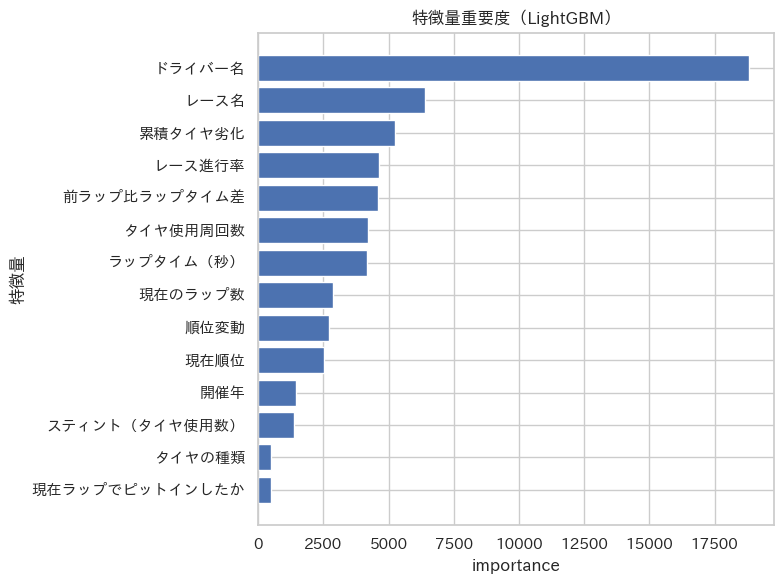

In [ ]:
# =========================
# 8-1) 特徴量重要度の確認
# =========================

# 解釈用に全データで1モデル学習
final_model = lgb.LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    n_estimators=2000,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

final_model.fit(
    X,
    y,
    categorical_feature=cat_cols_model
)

imp = (
    pd.DataFrame({
        "feature": X.columns,
        "日本語名": [jp(c) for c in X.columns],
        "importance": final_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print("【表】特徴量重要度")
display(imp.head(15))

imp_plot = imp.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))

plt.barh(
    imp_plot["日本語名"],
    imp_plot["importance"]
)

plt.title("特徴量重要度（LightGBM）")
plt.xlabel("importance")
plt.ylabel("特徴量")

plt.tight_layout()
plt.show()

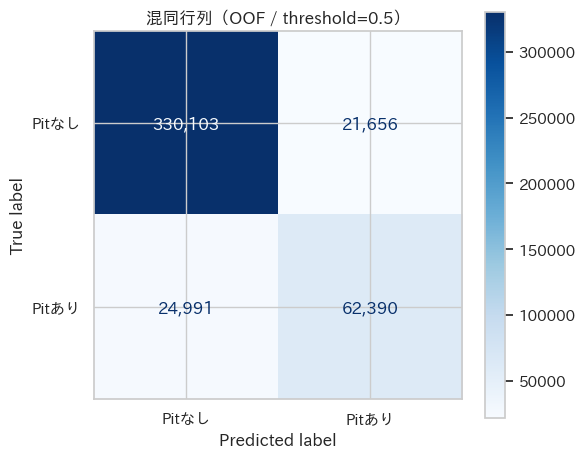

              precision    recall  f1-score   support

       Pitなし       0.93      0.94      0.93    351759
       Pitあり       0.74      0.71      0.73     87381

    accuracy                           0.89    439140
   macro avg       0.84      0.83      0.83    439140
weighted avg       0.89      0.89      0.89    439140



In [ ]:
# =========================
# 8-2) 混同行列（OOF）
# =========================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 7-4 Seed平均のOOF予測を使用
# AUC用の確率 → 0/1ラベルに変換
threshold = 0.5

y_true = y
y_pred = (oof_pred_seed >= threshold).astype(int)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Pitなし", "Pitあり"]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=",d"
)

plt.title("混同行列（OOF / threshold=0.5）")
plt.tight_layout()
plt.show()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Pitなし", "Pitあり"]
    )
)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


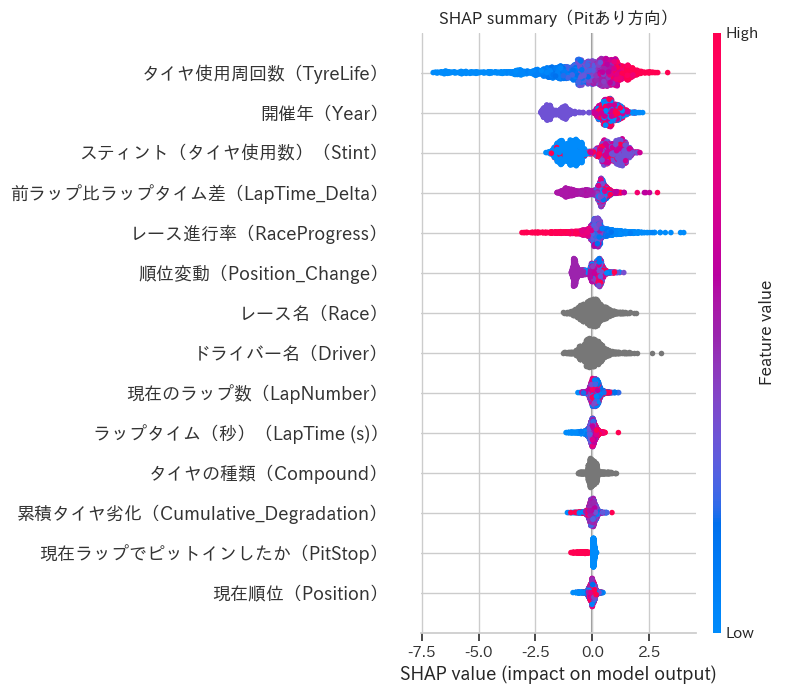

In [ ]:
# =========================
# 8-3) SHAPによるモデル解釈（二値分類）
# =========================

try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

# データが大きいためサンプリング
X_small = X.sample(
    2000,
    random_state=42
)

# SHAP explainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_small)

# 可視化用に列名を日本語＋英語にする
X_small_jp = X_small.copy()
X_small_jp.columns = [
    f"{jp(c)}（{c}）"
    for c in X_small.columns
]

# LightGBM二値分類では list で返る場合がある
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap.summary_plot(
    shap_values_plot,
    X_small_jp,
    show=False
)

plt.title("SHAP summary（Pitあり方向）")
plt.tight_layout()
plt.show()

## 8. 妥当性確認（結果）

### **8-1) 特徴量重要度の確認**
目的：LightGBMがどの特徴量を重視して予測しているか確認する

確認結果：
*  最も重要度が高かったのは ドライバー名（Driver） であった
*  次いで レース名（Race） が高く、コース特性やレースごとの戦略差を学習している可能性がある
*  数値特徴量では以下の特徴量で重要度が高かった
    *  累積タイヤ劣化（Cumulative_Degradation）
    *  レース進行率（RaceProgress）
    *  前ラップ比ラップタイム差（LapTime_Delta）
    *  タイヤ使用周回数（TyreLife）

*  一方で、以下の特徴量は重要度が比較的低かった
    *  タイヤの種類（Compound）
    *  現在ラップでピットインしたか（PitStop）

*  ピット戦略予測では、**タイヤ状態・レース進行状況・ドライバー／レース特性**が重要な要素であることが確認できた

### **8-2) 混同行列（OOF）**
目的：モデルがどのクラスをどの程度正しく判定できているか確認する

確認結果：
*  Pitなしは、330,103件を正しくPitなしと予測できている
*  PitなしをPitありと誤判定した件数は21,656件
*  Pitありは、62,390件を正しくPitありと予測できている
*  PitありをPitなしと誤判定した件数は24,991件
*  PitなしのRecallは0.94で高く、安定して判定できている
*  PitありのRecallは0.71で、一定程度検出できている
*  PitありはPitなしに比べて予測が難しく、見逃しが残っている
*  クラス不均衡がある中では、全体として良好な分類性能と考えられる

全体：
*  Accuracy：0.89
*  Macro F1：0.83

考察：
*  Pitなしは高精度で予測できている
*  PitありもRecall 0.71を確保している
*  クラス不均衡（Pitあり約20%）を考慮すると十分良好な性能
*  一部のPitありをPitなしと誤判定しているため、Recall改善余地は残る
*  ROC-AUC 0.943 と整合する良好な分類性能が確認できた

### **8-3) SHAPによるモデル解釈**
目的：モデルがどの特徴量を利用して「Pitあり」を予測しているか確認する

確認結果：
*  SHAPでは以下の特徴量の影響が大きかった。
    *  タイヤ使用周回数（TyreLife）
    *  開催年（Year）
    *  スティント（Stint）
    *  前ラップ比ラップタイム差（LapTime_Delta）
    *  レース進行率（RaceProgress）

特に

**タイヤ使用周回数（TyreLife）**
*  値が大きいほどSHAP値が正方向へ移動
*  タイヤを長く使用しているほどPitありに寄与

**スティント（Stint）**
*  Stintが増えるほどPitありに寄与
*  タイヤ交換回数と戦略が関連していることを示唆

**レース進行率（RaceProgress）**
*  レース中盤〜終盤でPitあり方向へ寄与
*  ピットタイミングがレース進行に依存していることが確認できる

**前ラップ比ラップタイム差（LapTime_Delta）**
*  ラップタイム変化が大きい場合にPitあり方向へ寄与
*  タイヤ性能低下を反映している可能性が高い

----
### **8章まとめ**
*  ROC-AUC：0.943
*  Public Score：0.94293
*  モデルは十分な予測性能を持つ
*  ピット戦略予測には以下の特徴量が重要であることが確認できた
    *  タイヤ使用周回数
    *  タイヤ劣化
    *  レース進行率
    *  スティント
    *  ラップタイム変化
*  特徴量重要度とSHAPの結果は概ね整合している
*  次の改善はパラメータ調整よりも 特徴量エンジニアリング中心 が有効と考えられる

## 9. 特徴量追加

In [ ]:
# 9-1) 特徴量追加①
train["TyreLife_x_RaceProgress"] = (
    train["TyreLife"]
    * train["RaceProgress"]
)

test["TyreLife_x_RaceProgress"] = (
    test["TyreLife"]
    * test["RaceProgress"]
)

train["TyreLife_ratio"] = (
    train["TyreLife"]
    / train["LapNumber"]
)

test["TyreLife_ratio"] = (
    test["TyreLife"]
    / test["LapNumber"]
)

In [ ]:
# 9-2) 特徴量追加②：Stint × TyreLife

train["Stint_x_TyreLife"] = (
    train["Stint"] * train["TyreLife"]
)

test["Stint_x_TyreLife"] = (
    test["Stint"] * test["TyreLife"]
)

9-1) 特徴量追加①

追加特徴量：
*  TyreLife_x_RaceProgress
*  TyreLife_ratio

目的：
*  タイヤ使用状況とレース進行状況の関係を表現する
*  レース全体に対するタイヤの使用割合を表現する

結果：
*  CV AUC = 0.94440
*  Public Score = 0.94387

確認結果：
*  ベースラインおよびSeed平均モデルを上回った
*  CV・Publicともに改善した
*  SHAPで重要だった TyreLife と RaceProgress の組み合わせが有効であった可能性が高い
*  タイヤの劣化状況をより直接的に表現できたことで予測性能が向上したと考えられる

## 10. 提出履歴（記録用）
*

## **まとめ**
### **1. データ理解**

* train/testの件数、目的変数、特徴量の種類を確認した
* 「1行が何を表しているか」を確認し、今回は「あるドライバーのある周回時点」のデータとして捉えた
* 欠損・重複・idの一意性も確認した

### **2. ドメイン理解**

* F1のピット判断に関係する要素を整理した
* タイヤ劣化だけでなく、レース進行、順位争い、アンダーカット、トラックポジションなども関係すると考えた

### **3. EDA**

* 目的変数の分布、数値特徴量、カテゴリ特徴量の傾向を確認した
* Pitあり/なしで、タイヤ使用周回数やレース進行率などに差があることを確認した

### **4. ベースラインモデル作成**

* まずは最小限の前処理でLightGBMモデルを作成した
* ベースライン性能を確認し、以降の改善比較の基準にした

### **5. モデル解釈**

* 特徴量重要度やSHAPを使い、モデルが何を見て判断しているかを確認した
* タイヤ使用周回数、レース進行率、ラップタイム変化などが重要そうだと分かった

### **6. 特徴量エンジニアリング**

* モデル解釈の結果をもとに、新しい特徴量を作成した
* TyreLife × RaceProgress：タイヤの古さ × レース進行状況
* TyreLife ÷ LapNumber：レース全体に対するタイヤ使用割合
* 単独の特徴量ではなく、タイヤ状態とレース状況を組み合わせて戦略を表現することを狙った

### **7. モデル改善**

* ベースラインモデルを基準に、改善施策を順番に検証した
* ベースラインでは、CV AUC：0.94270、Public Score：0.94277
* LightGBMのパラメータ調整を行ったが、CV AUC：0.94207、Public Score：0.94238 と改善しなかった
* 次にSeed平均を行い、CV AUC：0.94364、Public Score：0.94293 まで改善した
* さらに特徴量を追加した結果、CV AUC：0.94440、Public Score：0.94387 まで改善した
* 結果として、パラメータ調整よりも、Seed平均と特徴量エンジニアリングの方が効果的だった

### **8. 妥当性確認**

* 混同行列やSHAPで、モデルの予測傾向を確認した
* Pitなしは高精度で判定できていたが、Pitありの見逃しは残っていた

### **9. 時間があったらやりたかったこと**

* 今後は誤分類分析を行い、どのような戦略パターンを外しているか確認する
* その結果をもとに、さらに特徴量追加を検討する

## **Appendix**

